# S04 Merapi Results Analysis

Lightweight post-processing analyses for cached Merapi AIMS4PT results.

## Setup

In [43]:
%matplotlib inline

from pathlib import Path
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
import pickle as pkl
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _find_project_root(start=None):
    """Find the project root by walking upward from the current directory."""
    path = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (path, *path.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find pyproject.toml above the current directory.")


PROJECT_ROOT = _find_project_root()
PAPER_DIR = PROJECT_ROOT / "paper"
DATA_DIR = PAPER_DIR / "data"
IMAGES_DIR = PAPER_DIR / ".images"
timestamp = "add_pre-2006_028"
CACHE_DIR = PAPER_DIR / ".cache" / timestamp

for _dir in (DATA_DIR, IMAGES_DIR, CACHE_DIR):
    _dir.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


## Load Cached Inputs

In [44]:
print(f"Using cached Merapi results from: {CACHE_DIR}")


Using cached Merapi results from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\add_pre-2006_028


In [45]:
def read_pairing_cache(cache_path):
    """Read cached Kd pairing results written by the Merapi application notebook."""
    cache_path = Path(cache_path)
    if not cache_path.exists():
        raise FileNotFoundError(f"Missing pairing cache: {cache_path}")

    pairs = pd.read_excel(cache_path, sheet_name="pairs")
    mask_df = pd.read_excel(cache_path, sheet_name="pairs_pass_mask")
    cleaned_minerals = pd.read_excel(cache_path, sheet_name="cleaned_minerals")
    cleaned_liquids = pd.read_excel(cache_path, sheet_name="cleaned_liquids")

    mask_values = mask_df["pairs_pass_mask"]
    if mask_values.dtype == object:
        pairs_pass_mask = mask_values.astype(str).str.lower().isin(["true", "1", "yes"])
    else:
        pairs_pass_mask = mask_values.astype(bool)
    pairs_pass_mask.index = pairs.index
    return pairs, pairs_pass_mask, cleaned_minerals, cleaned_liquids


def load_pairing_cache_for_year(year):
    """Load paired Merapi rows and add the liquid H2O estimate used downstream."""
    cache_path = CACHE_DIR / f"merapi_{year}_pairing_kd028_err1e-4_n20000_endmembers.xlsx"
    pairs, pairs_pass_mask, paired_cpx, paired_liq = read_pairing_cache(cache_path)
    paired_cpx_pass = paired_cpx[pairs_pass_mask].reset_index(drop=True)
    paired_liq_pass = paired_liq[pairs_pass_mask].reset_index(drop=True)
    paired_liq_pass["H2O"] = pd.to_numeric(paired_liq_pass["SiO2"], errors="coerce") * 0.06995 + 0.383
    print(f"Loaded {year} paired rows: {len(paired_cpx_pass)} pass / {len(paired_cpx)} total")
    return cache_path, pairs, pairs_pass_mask, paired_cpx, paired_liq, paired_cpx_pass, paired_liq_pass


(
    pairing_cache_2006,
    pairs_06,
    pairs_pass_mask_06,
    paired_cpx_06,
    paired_liq_06,
    paired_cpx_06_pass,
    paired_liq_06_pass,
) = load_pairing_cache_for_year("2006")

(
    pairing_cache_2010,
    pairs_10,
    pairs_pass_mask_10,
    paired_cpx_10,
    paired_liq_10,
    paired_cpx_10_pass,
    paired_liq_10_pass,
) = load_pairing_cache_for_year("2010")

Loaded 2006 paired rows: 42 pass / 170 total
Loaded 2010 paired rows: 106 pass / 305 total


In [46]:
WORKFLOW_CASE_SPECS = [
    {
        "model_kind": "P",
        "phase_key": "cpx_only",
        "phase_label": "Clinopyroxene-only",
        "year": "2006",
        "variable_name": "workflow_cpx_only_P_06",
    },
    {
        "model_kind": "P",
        "phase_key": "cpx_only",
        "phase_label": "Clinopyroxene-only",
        "year": "2010",
        "variable_name": "workflow_cpx_only_P_10",
    },
    {
        "model_kind": "P",
        "phase_key": "cpx_liq",
        "phase_label": "Clinopyroxene-liquid",
        "year": "2006",
        "variable_name": "workflow_cpx_liq_P_06",
    },
    {
        "model_kind": "P",
        "phase_key": "cpx_liq",
        "phase_label": "Clinopyroxene-liquid",
        "year": "2010",
        "variable_name": "workflow_cpx_liq_P_10",
    },
    {
        "model_kind": "T",
        "phase_key": "cpx_only",
        "phase_label": "Clinopyroxene-only",
        "year": "2006",
        "variable_name": "workflow_cpx_only_T_06",
    },
    {
        "model_kind": "T",
        "phase_key": "cpx_only",
        "phase_label": "Clinopyroxene-only",
        "year": "2010",
        "variable_name": "workflow_cpx_only_T_10",
    },
    {
        "model_kind": "T",
        "phase_key": "cpx_liq",
        "phase_label": "Clinopyroxene-liquid",
        "year": "2006",
        "variable_name": "workflow_cpx_liq_T_06",
    },
    {
        "model_kind": "T",
        "phase_key": "cpx_liq",
        "phase_label": "Clinopyroxene-liquid",
        "year": "2010",
        "variable_name": "workflow_cpx_liq_T_10",
    },
]


def workflow_cache_path(year, model_kind, phase_key):
    """Return the cached Merapi workflow path for one model-selection case."""
    return CACHE_DIR / f"marapi_{year}_{model_kind}_workflow_{phase_key}_{model_kind}_{timestamp}.pkl"


def load_cached_workflow_case(spec):
    """Load one cached workflow and expose it under the historical notebook name."""
    workflow_path = workflow_cache_path(spec["year"], spec["model_kind"], spec["phase_key"])
    if not workflow_path.exists():
        raise FileNotFoundError(f"Missing cached workflow: {workflow_path}")
    with open(workflow_path, "rb") as f:
        workflow = pkl.load(f)
    globals()[spec["variable_name"]] = workflow
    return workflow_path, workflow


workflow_cases = {}
workflow_summary_rows = []
for spec in WORKFLOW_CASE_SPECS:
    workflow_path, workflow = load_cached_workflow_case(spec)
    case_key = (spec["model_kind"], spec["phase_key"], spec["year"])
    workflow_cases[case_key] = workflow
    best_model_counts = workflow.get_best_model_series().value_counts(dropna=False)
    top_models = "; ".join(f"{model}: {count}" for model, count in best_model_counts.head(4).items())
    workflow_summary_rows.append(
        {
            "case": f"{spec['model_kind']} {spec['phase_label']} {spec['year']}",
            "n": int(best_model_counts.sum()),
            "top_selected_models": top_models,
            "path": workflow_path.name,
        }
    )

workflow_model_summary = pd.DataFrame(workflow_summary_rows)
display(workflow_model_summary)

,case,n,top_selected_models,path
0,P Clinopyroxene-only 2006,42,"Jorgenson et al., 2022 (cpx_only): 31; Petrell...",marapi_2006_P_workflow_cpx_only_P_add_pre-2006...
1,P Clinopyroxene-only 2010,106,"Petrelli et al., 2020 (cpx_only): 70; Jorgenso...",marapi_2010_P_workflow_cpx_only_P_add_pre-2006...
2,P Clinopyroxene-liquid 2006,42,"Petrelli et al., 2020 (cpx_liq): 25; Jorgenson...",marapi_2006_P_workflow_cpx_liq_P_add_pre-2006_...
3,P Clinopyroxene-liquid 2010,106,"Petrelli et al., 2020 (cpx_liq): 36; Jorgenson...",marapi_2010_P_workflow_cpx_liq_P_add_pre-2006_...
4,T Clinopyroxene-only 2006,42,"Higgins et al., 2021 (cpx_only): 18; Petrelli ...",marapi_2006_T_workflow_cpx_only_T_add_pre-2006...
5,T Clinopyroxene-only 2010,106,"Ágreda-López et al., 2024 (cpx_only): 63; Higg...",marapi_2010_T_workflow_cpx_only_T_add_pre-2006...
6,T Clinopyroxene-liquid 2006,42,"Chicchi et al., 2023 (cpx_liq): 29; Ágreda-Lóp...",marapi_2006_T_workflow_cpx_liq_T_add_pre-2006_...
7,T Clinopyroxene-liquid 2010,106,"Ágreda-López et al., 2024 (cpx_liq): 55; Chicc...",marapi_2010_T_workflow_cpx_liq_T_add_pre-2006_...


## Compositions Colored By Selected Model

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from paper.scripts.merapi_helpers import (
    _add_merapi_plot_columns,
    _merapi_pair_frame,
)

try:
    from paper.scripts.constants_illustration import get_model_abbreviation
except ImportError:
    get_model_abbreviation = None


MERAPI_SELECTED_MODEL_PAIR_FRAMES = {
    "2006": _add_merapi_plot_columns(_merapi_pair_frame(paired_cpx_06_pass, paired_liq_06_pass)),
    "2010": _add_merapi_plot_columns(_merapi_pair_frame(paired_cpx_10_pass, paired_liq_10_pass)),
}

SELECTED_MODEL_PANEL_SPECS = [
    {
        "key": "cpx_cao_mg_number",
        "kind": "cpx",
        "label": "(a)",
        "x_col": "CaO_cpx",
        "y_col": "MgNumber_cpx",
        "xlabel": r"Clinopyroxene CaO (wt%)",
        "ylabel": r"Clinopyroxene Mg#",
    },
    {
        "key": "cpx_na_al",
        "kind": "cpx",
        "label": "(b)",
        "x_col": "Na2O_cpx",
        "y_col": "Al2O3_cpx",
        "xlabel": r"Clinopyroxene Na$_2$O (wt%)",
        "ylabel": r"Clinopyroxene Al$_2$O$_3$ (wt%)",
    },
    {
        "key": "liquid_tas",
        "kind": "liquid",
        "label": "(c)",
        "x_col": "SiO2_liq",
        "y_col": "TotalAlkali_liq",
        "xlabel": r"Liquid SiO$_2$ (wt%)",
        "ylabel": r"Liquid Na$_2$O + K$_2$O (wt%)",
    },
    {
        "key": "liquid_sio2_mg_number",
        "kind": "liquid",
        "label": "(d)",
        "x_col": "SiO2_liq",
        "y_col": "MgNumber_liq",
        "xlabel": r"Liquid SiO$_2$ (wt%)",
        "ylabel": r"Liquid Mg#",
    },
]


def _align_selected_models_to_pairs(workflow, pair_df):
    # Prefer exact index alignment, then fall back to row order when lengths match.
    selected = workflow.get_best_model_series().astype("object")
    selected.name = "selected_model"
    if selected.index.equals(pair_df.index):
        return selected.reindex(pair_df.index)
    if len(selected) == len(pair_df):
        return pd.Series(selected.to_numpy(), index=pair_df.index, name="selected_model")
    out = pd.Series(np.nan, index=pair_df.index, dtype="object", name="selected_model")
    common_index = pair_df.index.intersection(selected.index)
    out.loc[common_index] = selected.loc[common_index].to_numpy()
    return out


def _short_selected_model_label(model_name, model_kind):
    # Use manuscript abbreviations when available, otherwise keep a compact model name.
    if pd.isna(model_name):
        return "No selected model"
    model_name = str(model_name)
    if get_model_abbreviation is not None:
        label = get_model_abbreviation(model_name, model_kind)
        if label != model_name:
            return label
    return model_name.split("(")[0].strip()


def _collapse_low_frequency_selected_models(df, *, min_pct=5.0):
    """Group selected models below a percentage threshold into Other."""
    out = df.copy()
    selected = out["selected_model"].where(out["selected_model"].notna(), "No selected model").astype(str)
    pct = selected.value_counts(normalize=True, dropna=False).mul(100.0)
    colored_models = pct[pct >= min_pct].index.tolist()
    out["selected_model_group"] = selected.where(selected.isin(colored_models), "Other")
    return out, colored_models, pct


def _selected_model_palette(model_order):
    # Use Matplotlib's default C-cycle for stronger categorical contrast.
    return {model_name: f"C{i % 10}" for i, model_name in enumerate(model_order)}


def _scatter_selected_models(ax, df, x_col, y_col, model_colors, *, marker="o", size=20, zorder=5):
    x = pd.to_numeric(df[x_col], errors="coerce")
    y = pd.to_numeric(df[y_col], errors="coerce")
    valid = x.notna() & y.notna()
    data = df.loc[valid].copy()
    if data.empty:
        return
    data["selected_model_group"] = data["selected_model_group"].where(data["selected_model_group"].notna(), "Other").astype(str)
    for model_name, group in data.groupby("selected_model_group", sort=False):
        ax.scatter(
            pd.to_numeric(group[x_col], errors="coerce"),
            pd.to_numeric(group[y_col], errors="coerce"),
            marker=marker,
            s=size,
            facecolors=model_colors.get(model_name, "0.82"),
            edgecolors="0.15",
            linewidths=0.3,
            alpha=0.9,
            zorder=zorder,
        )


def _selected_model_pair_frame(year, workflow):
    """Build one composition frame with selected-model assignments."""
    pair_frame = MERAPI_SELECTED_MODEL_PAIR_FRAMES[str(year)].copy()
    pair_frame["selected_model"] = _align_selected_models_to_pairs(workflow, pair_frame)
    pair_frame["eruption_year"] = str(year)
    pair_frame["liquid_group"] = "equilibrium liquid"
    return pair_frame


def plot_merapi_compositions_by_selected_model(year, phase_label, model_kind, workflow, *, figure_name=None):
    """Plot Merapi cpx and liquid compositions colored by selected workflow model."""
    year = str(year)
    selected_pairs = _selected_model_pair_frame(year, workflow)
    selected_pairs, model_order, model_pct = _collapse_low_frequency_selected_models(selected_pairs, min_pct=5.0)
    model_colors = _selected_model_palette(model_order)
    figure_name = figure_name or (
        f"fig_7_Merapi_{year}_compositions_by_selected_{model_kind}_{phase_label.lower().replace('-', '_')}_model"
    )

    fig, axes = plt.subplots(2, 2, figsize=(8.2, 7.2), dpi=300)
    for ax, spec in zip(axes.ravel(), SELECTED_MODEL_PANEL_SPECS):
        _scatter_selected_models(
            ax,
            selected_pairs,
            spec["x_col"],
            spec["y_col"],
            model_colors,
            size=20 if spec["kind"] == "cpx" else 16,
        )

        ax.autoscale(enable=True, axis="both", tight=False)
        ax.margins(x=0.06, y=0.06)
        ax.grid(True, color="0.92", linewidth=0.4)
        ax.tick_params(labelsize=10)
        ax.set_xlabel(spec["xlabel"], fontsize=11)
        ax.set_ylabel(spec["ylabel"], fontsize=11)
        ax.text(
            0.0,
            1.015,
            spec["label"],
            transform=ax.transAxes,
            va="bottom",
            ha="left",
            fontsize=12,
            fontweight="bold",
            clip_on=False,
        )

    model_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=model_colors[model_name],
            markeredgecolor="0.15",
            markersize=5,
            label=_short_selected_model_label(model_name, model_kind),
        )
        for model_name in model_order
    ]
    fig.legend(
        handles=model_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.95),
        ncol=min(4, max(len(model_handles), 1)),
        frameon=True,
        fontsize=8.5,
        title=f"{year} selected {model_kind} model",
        title_fontsize=9.5,
    )
    fig.suptitle(f"{model_kind} {phase_label} {year}", y=0.995, fontsize=13)
    fig.tight_layout(rect=(0, 0, 1, 0.90))
    print(figure_name)
    return fig, axes, selected_pairs, model_order

### Pressure Models

#### P Clinopyroxene-only 2006

fig_7_Merapi_2006_compositions_by_selected_P_cpx_only_model


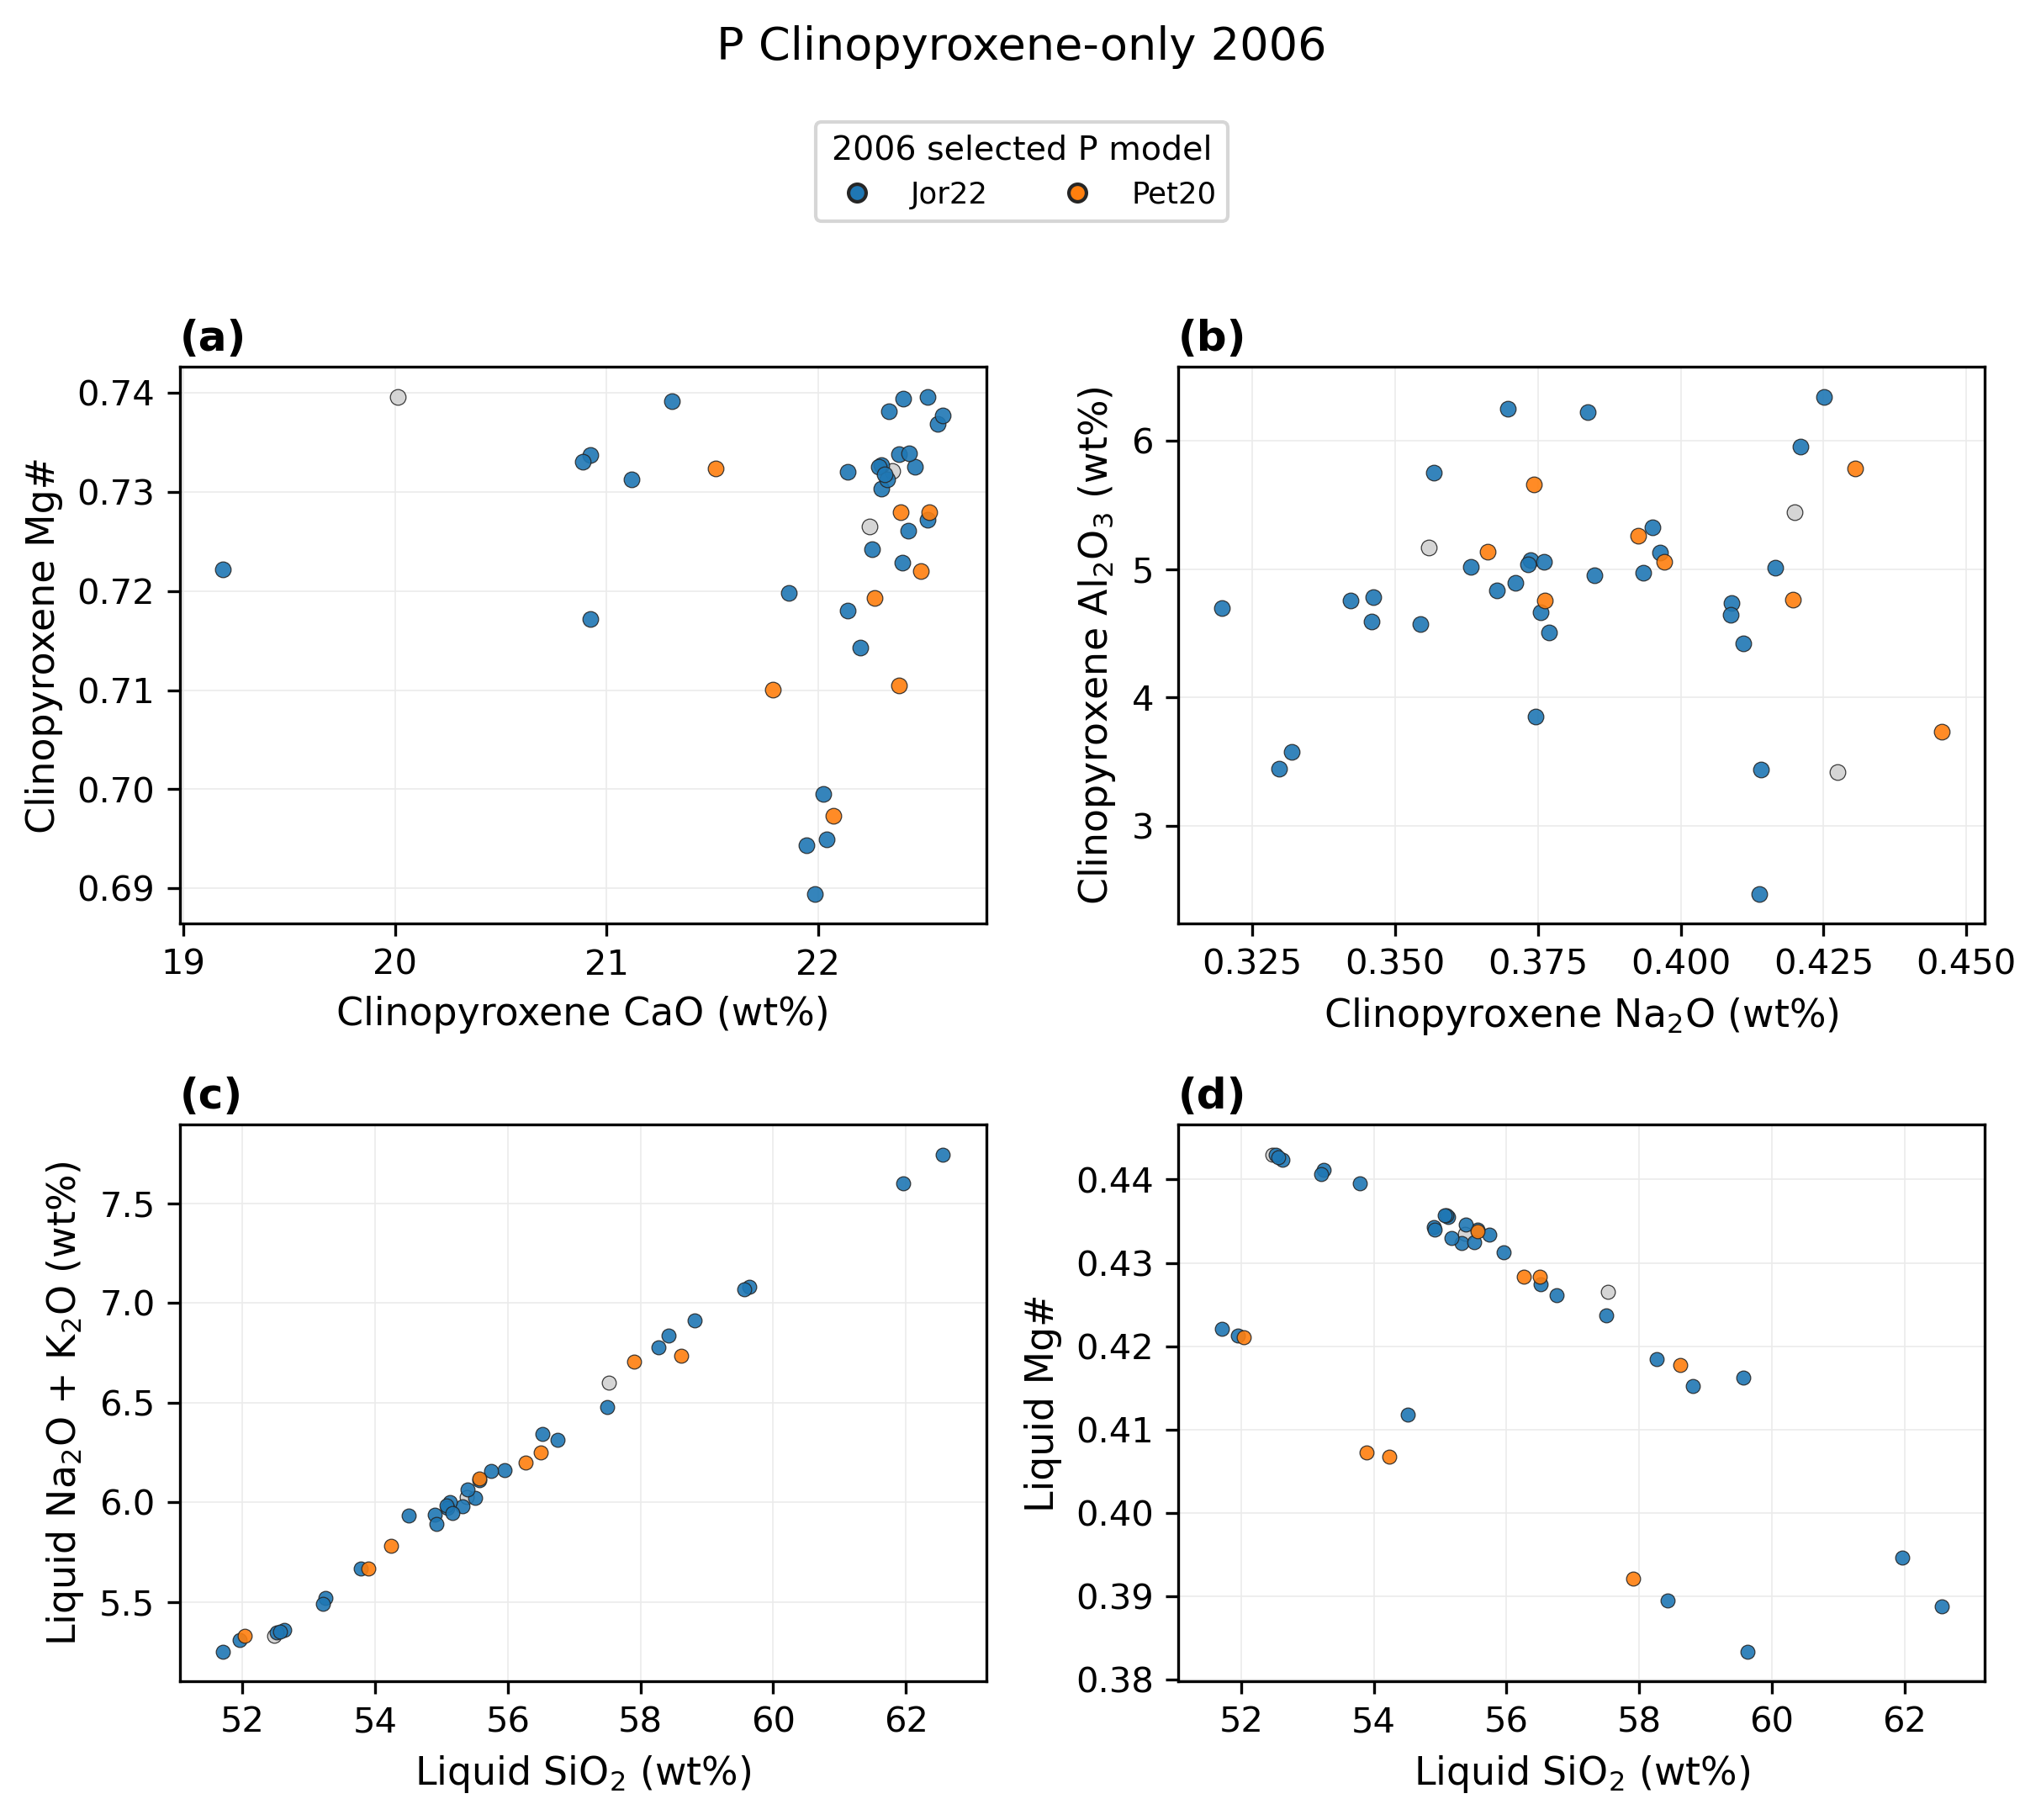

In [48]:
fig_p_cpx_only_2006, axes_p_cpx_only_2006, data_p_cpx_only_2006, models_p_cpx_only_2006 = plot_merapi_compositions_by_selected_model(
    year="2006",
    phase_label="Clinopyroxene-only",
    model_kind="P",
    workflow=workflow_cpx_only_P_06,
    figure_name="fig_7_Merapi_2006_compositions_by_selected_P_cpx_only_model",
)
plt.show()

#### P Clinopyroxene-only 2010

fig_7_Merapi_2010_compositions_by_selected_P_cpx_only_model


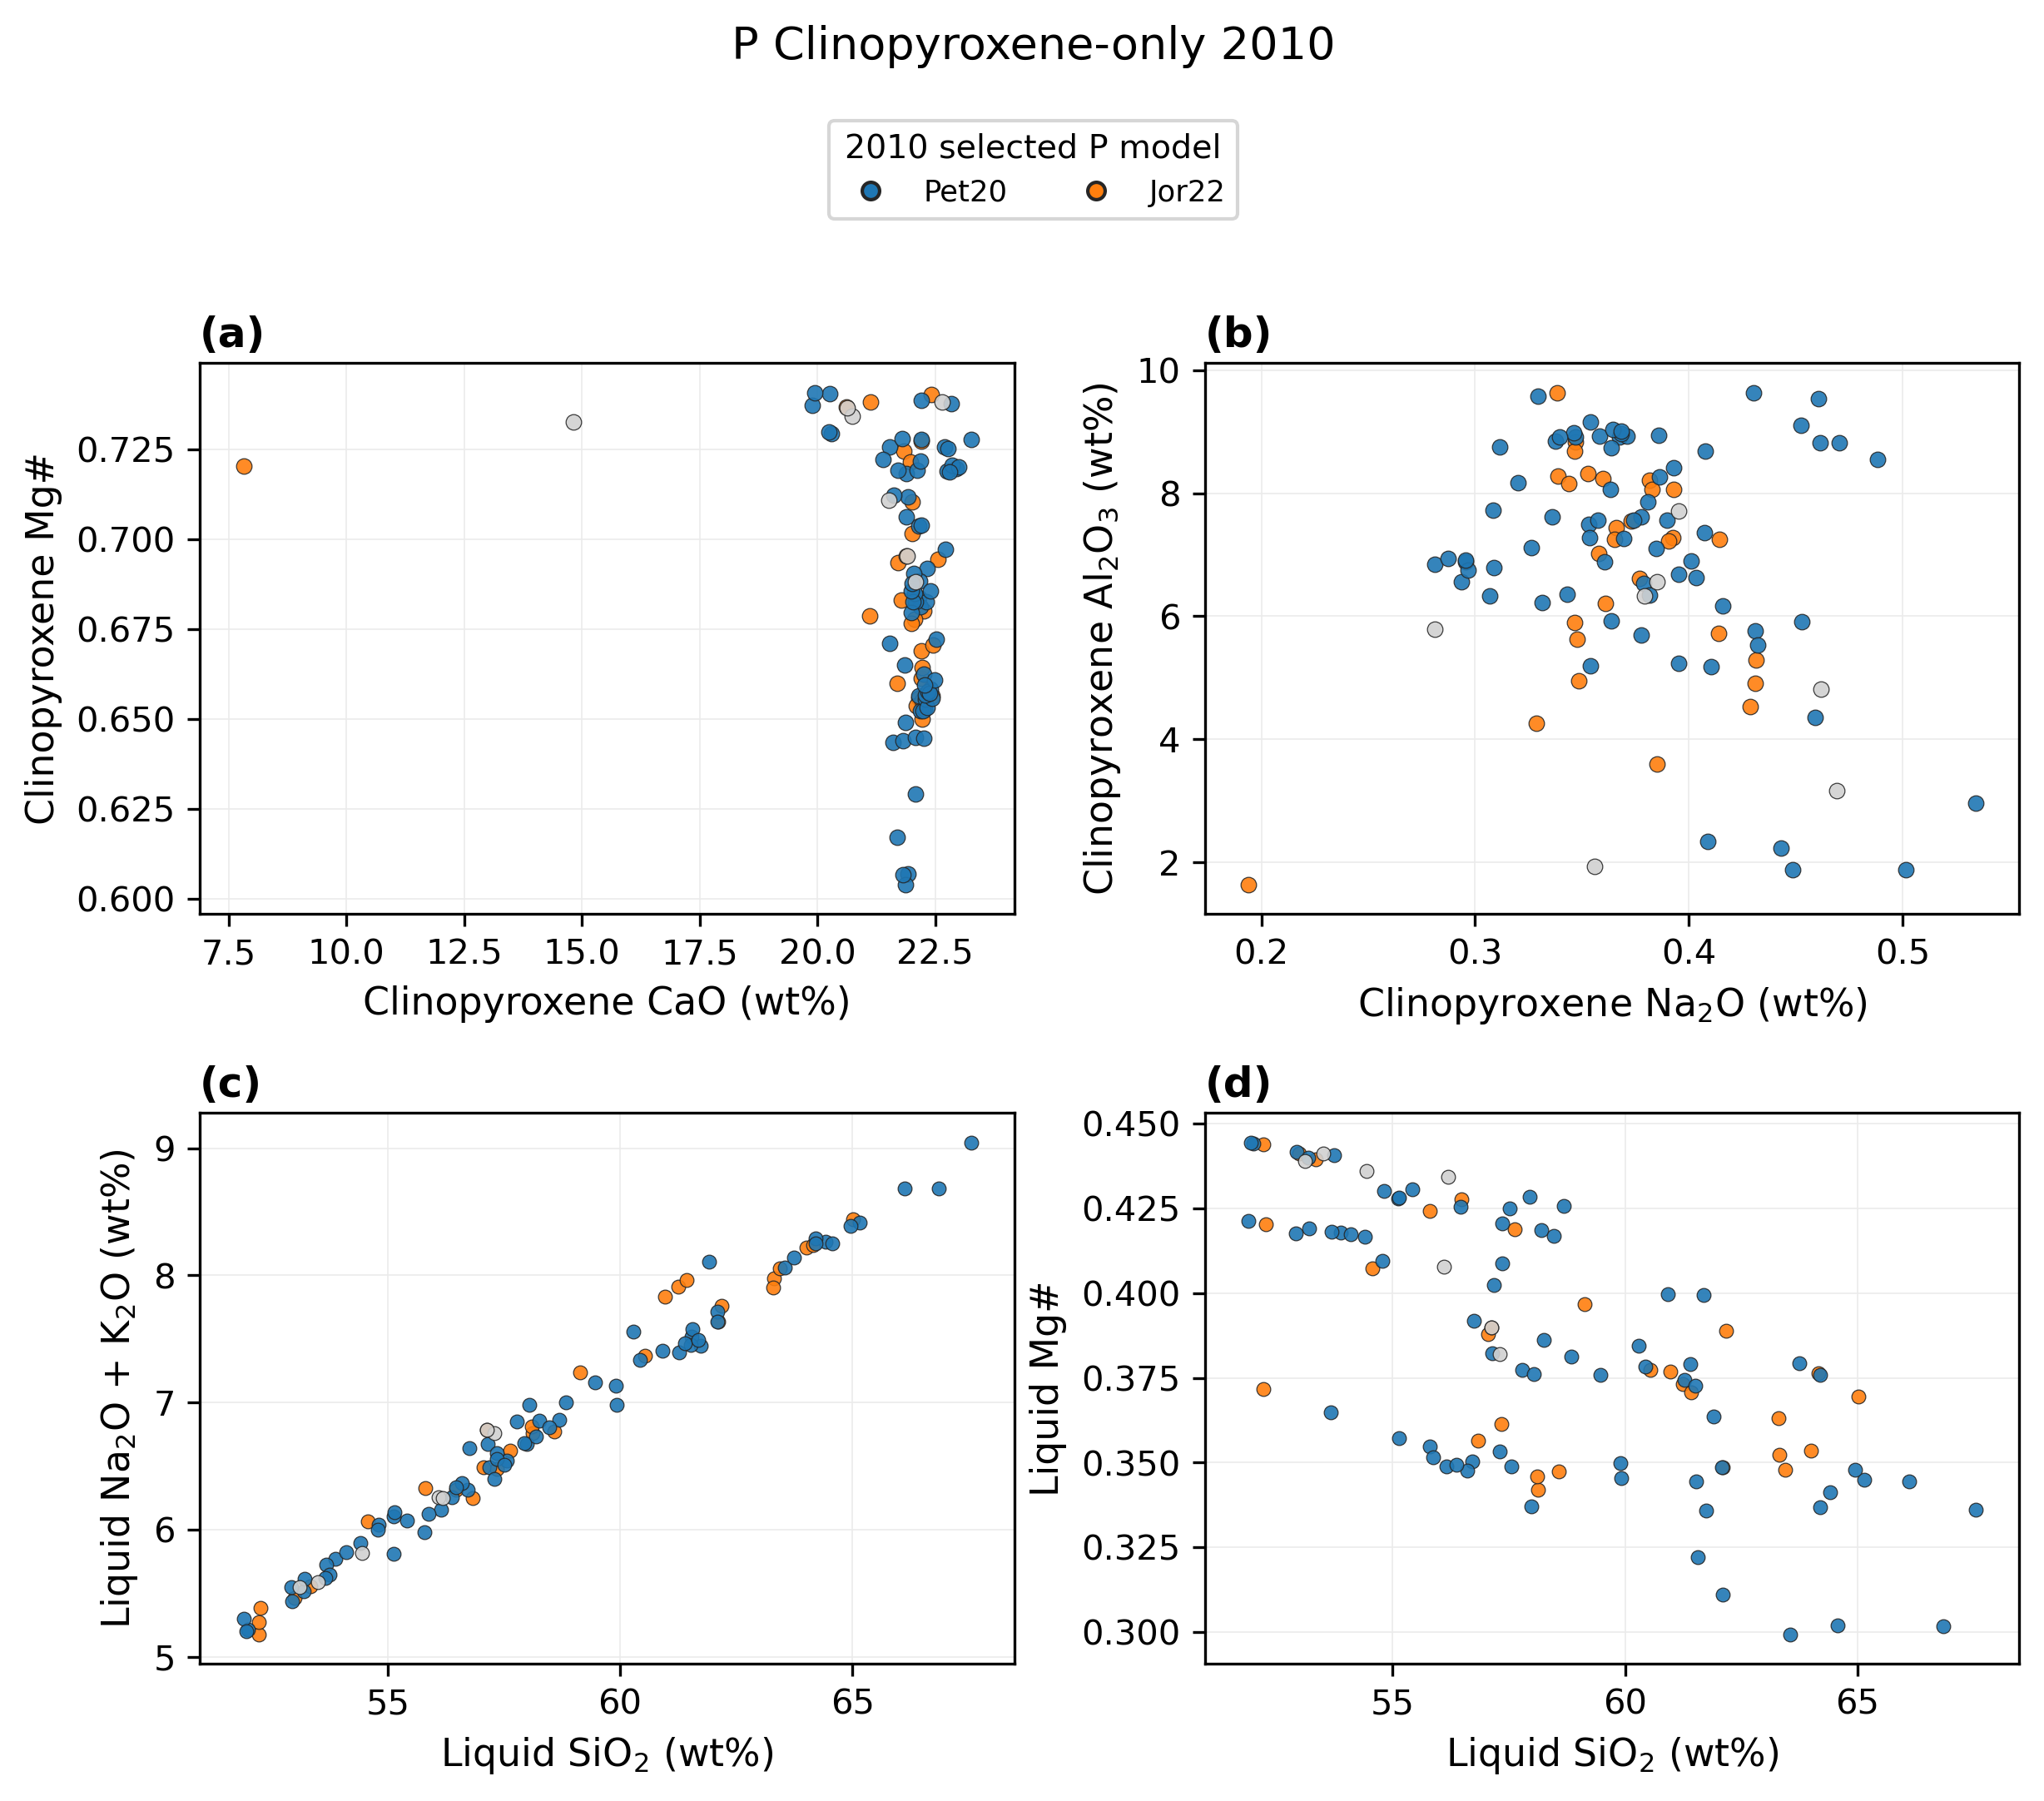

In [49]:
fig_p_cpx_only_2010, axes_p_cpx_only_2010, data_p_cpx_only_2010, models_p_cpx_only_2010 = plot_merapi_compositions_by_selected_model(
    year="2010",
    phase_label="Clinopyroxene-only",
    model_kind="P",
    workflow=workflow_cpx_only_P_10,
    figure_name="fig_7_Merapi_2010_compositions_by_selected_P_cpx_only_model",
)
plt.show()

#### P Clinopyroxene-liquid 2006

fig_7_Merapi_2006_compositions_by_selected_P_cpx_liq_model


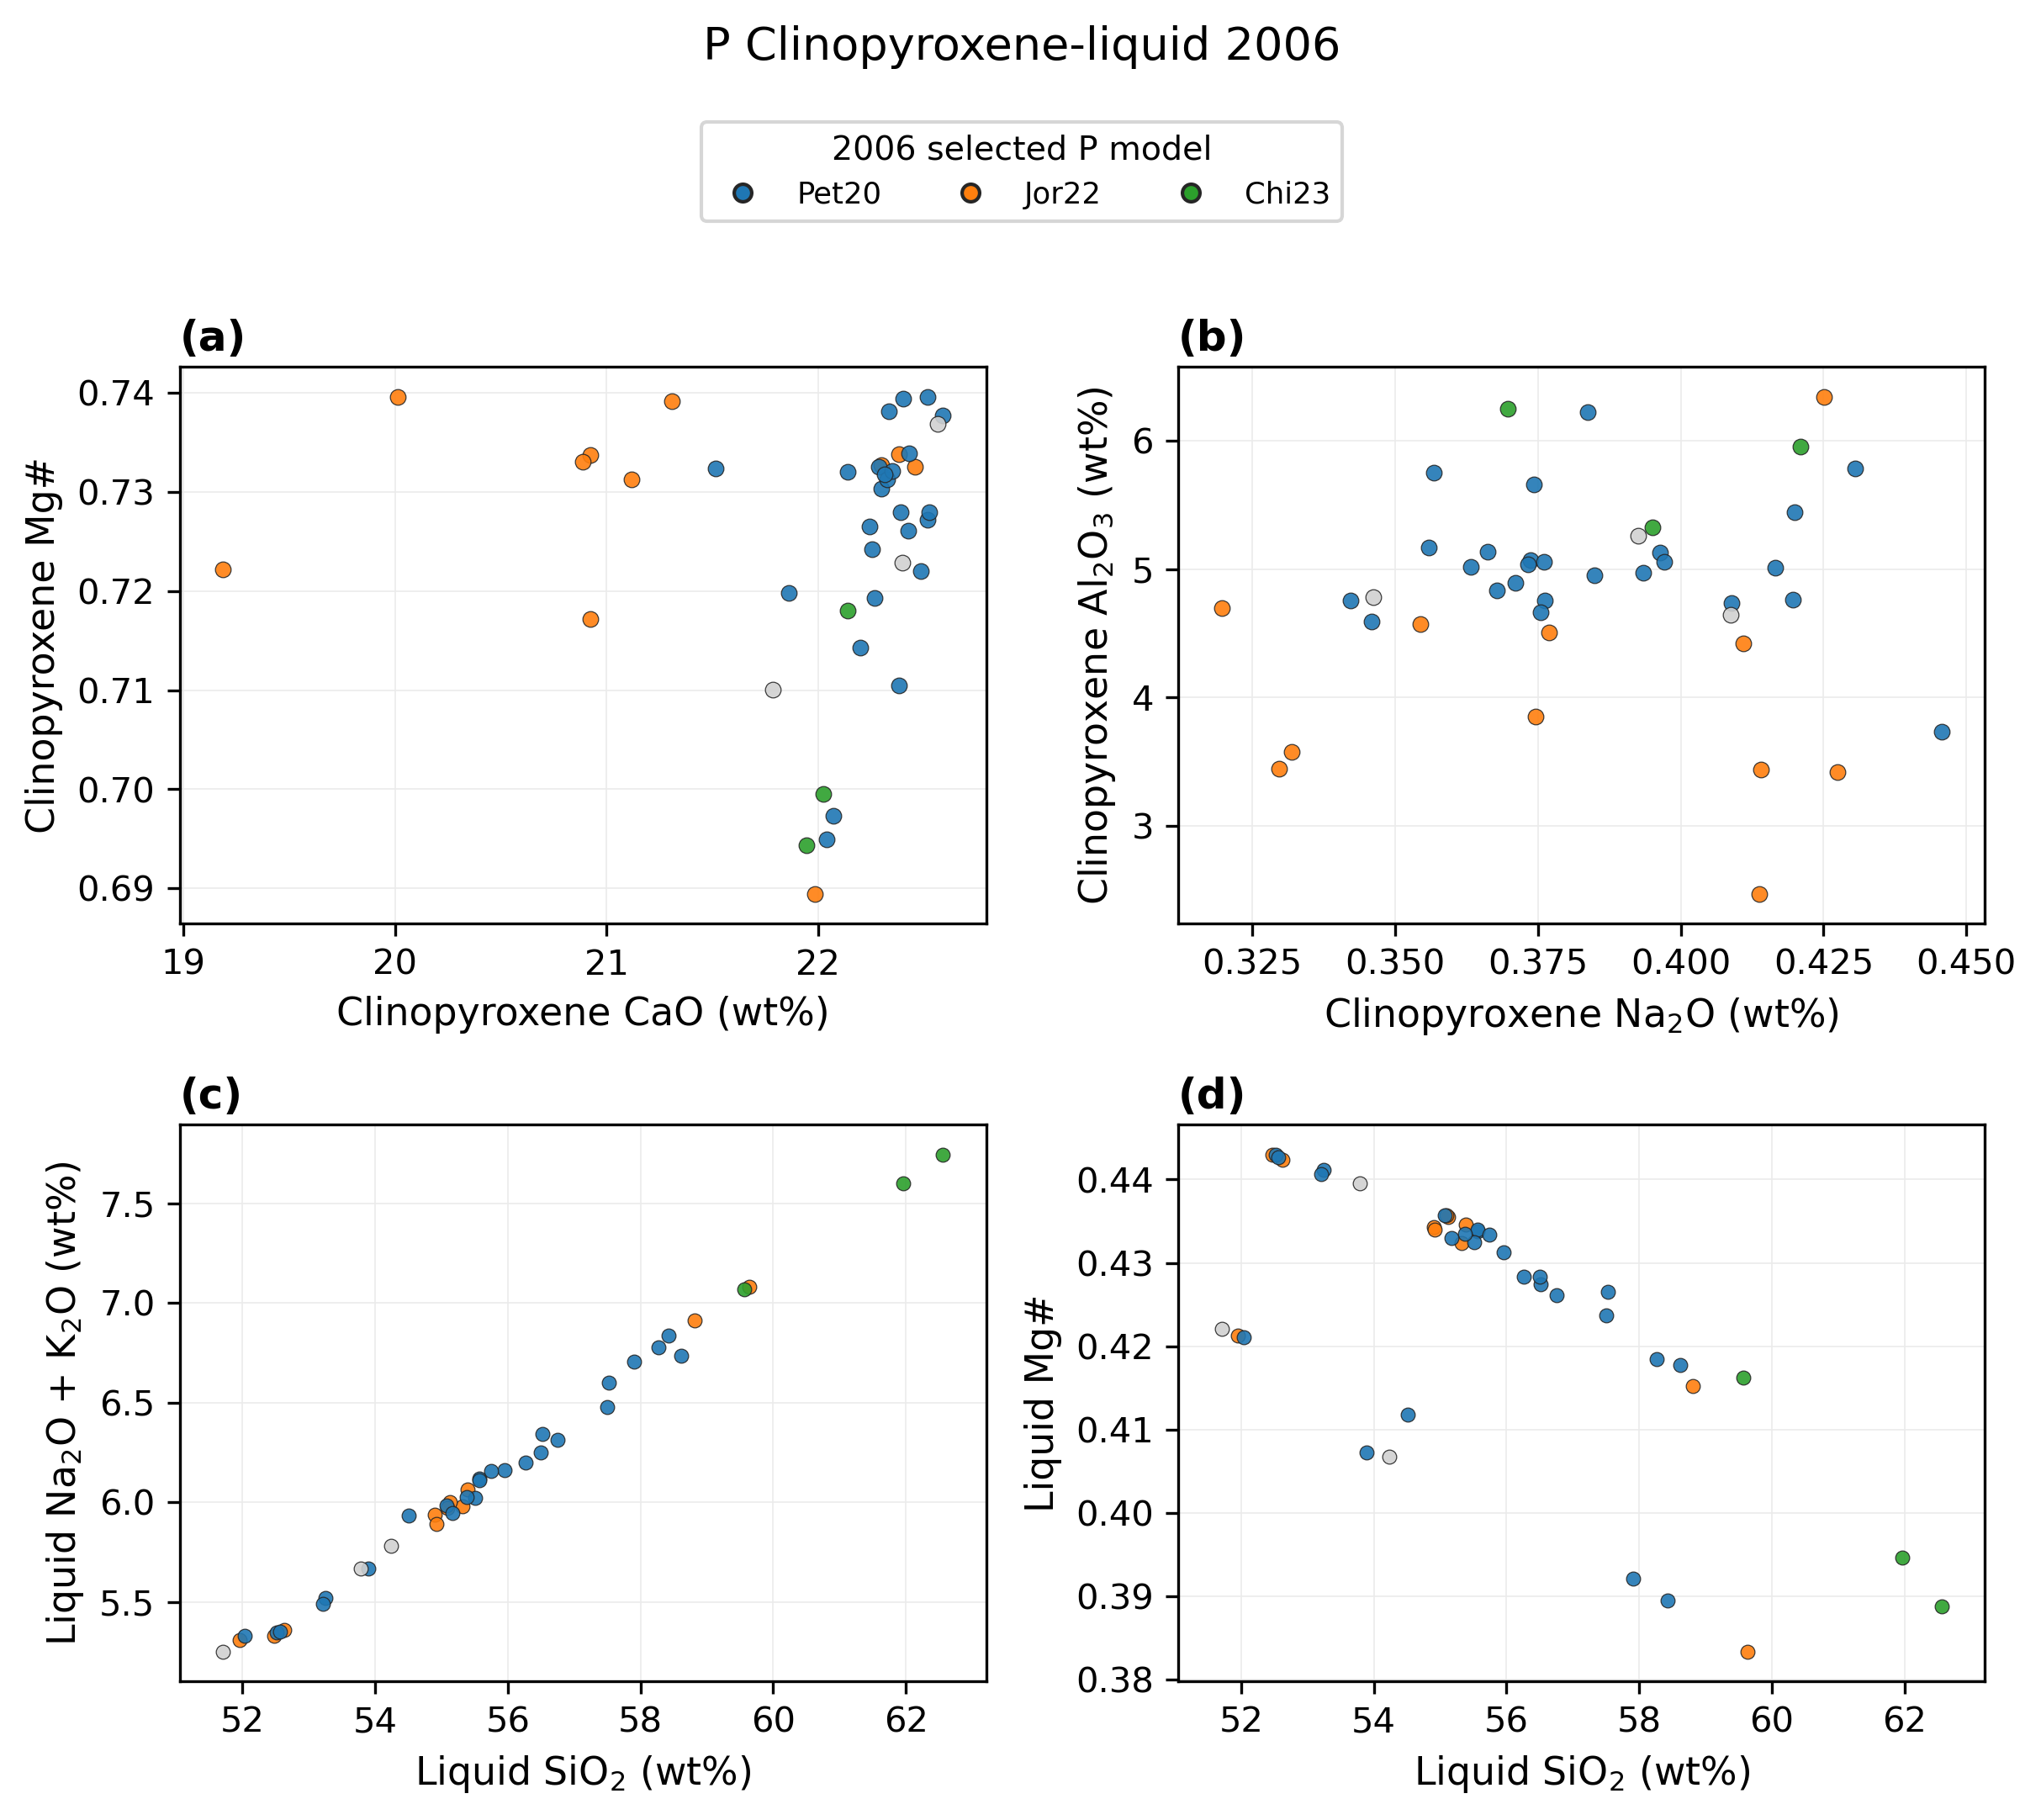

In [50]:
fig_p_cpx_liq_2006, axes_p_cpx_liq_2006, data_p_cpx_liq_2006, models_p_cpx_liq_2006 = plot_merapi_compositions_by_selected_model(
    year="2006",
    phase_label="Clinopyroxene-liquid",
    model_kind="P",
    workflow=workflow_cpx_liq_P_06,
    figure_name="fig_7_Merapi_2006_compositions_by_selected_P_cpx_liq_model",
)
plt.show()

#### P Clinopyroxene-liquid 2010

fig_7_Merapi_2010_compositions_by_selected_P_cpx_liq_model


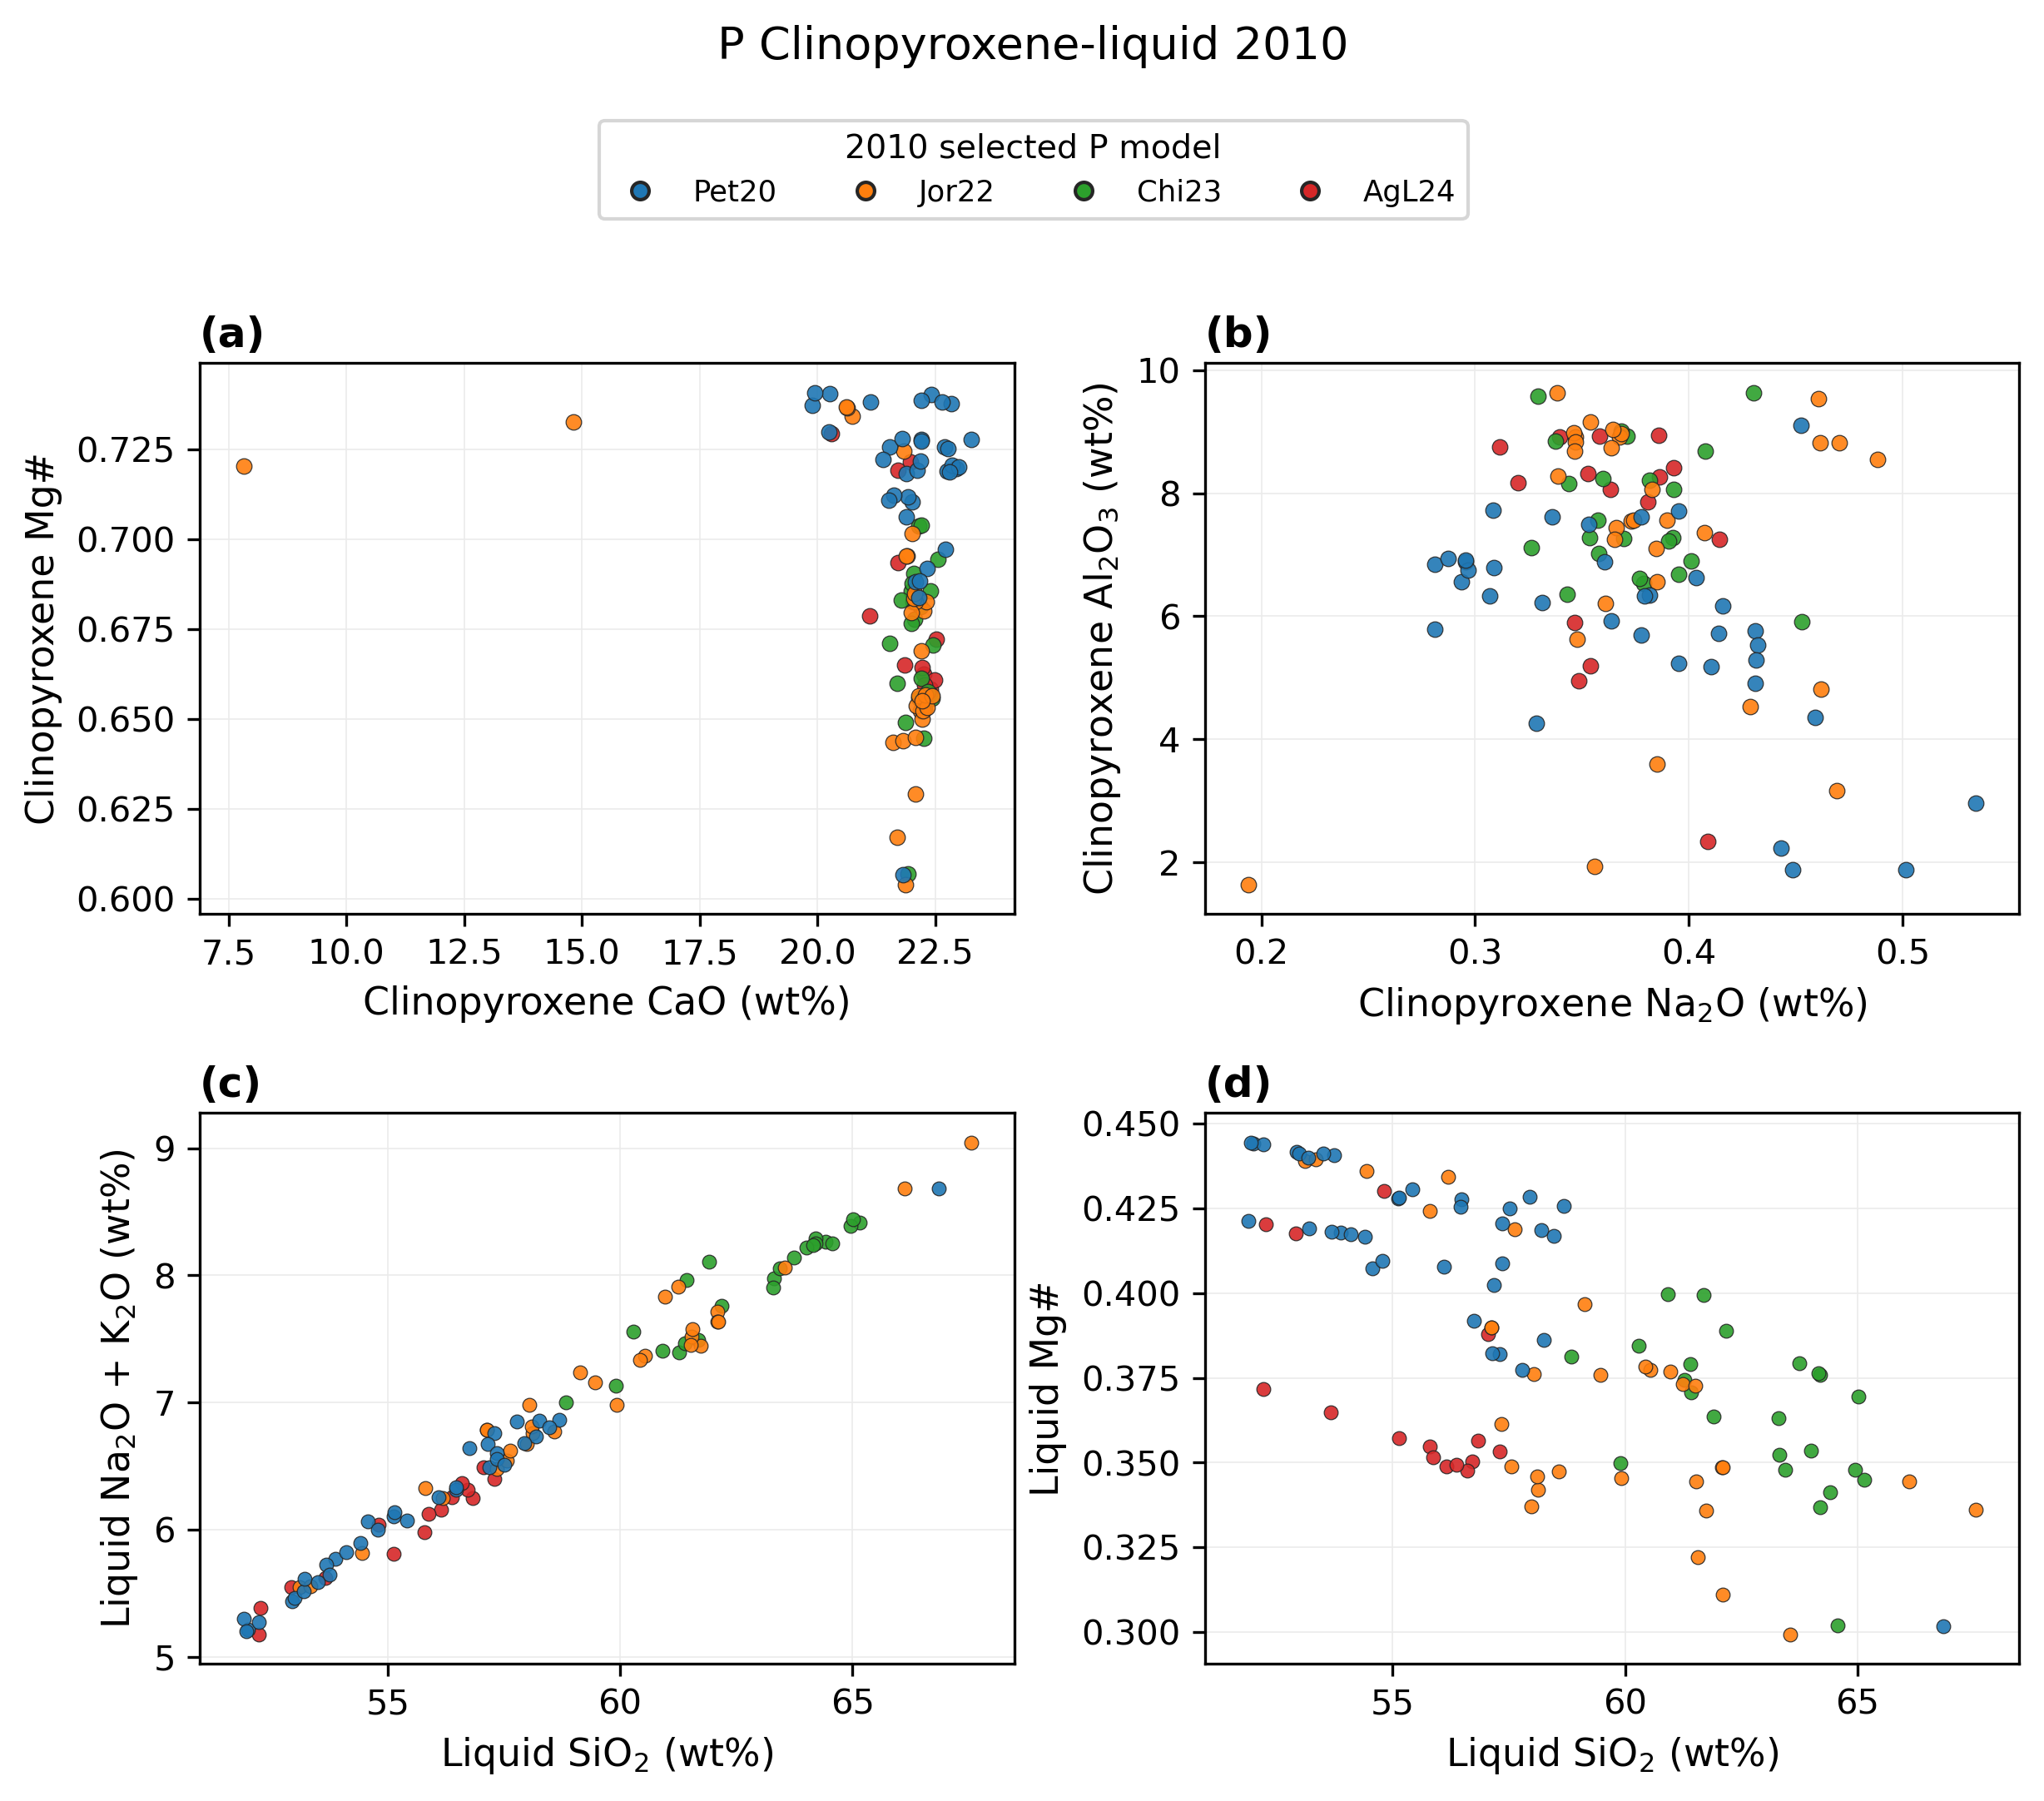

In [51]:
fig_p_cpx_liq_2010, axes_p_cpx_liq_2010, data_p_cpx_liq_2010, models_p_cpx_liq_2010 = plot_merapi_compositions_by_selected_model(
    year="2010",
    phase_label="Clinopyroxene-liquid",
    model_kind="P",
    workflow=workflow_cpx_liq_P_10,
    figure_name="fig_7_Merapi_2010_compositions_by_selected_P_cpx_liq_model",
)
plt.show()

### Temperature Models

#### T Clinopyroxene-only 2006

fig_7_Merapi_2006_compositions_by_selected_T_cpx_only_model


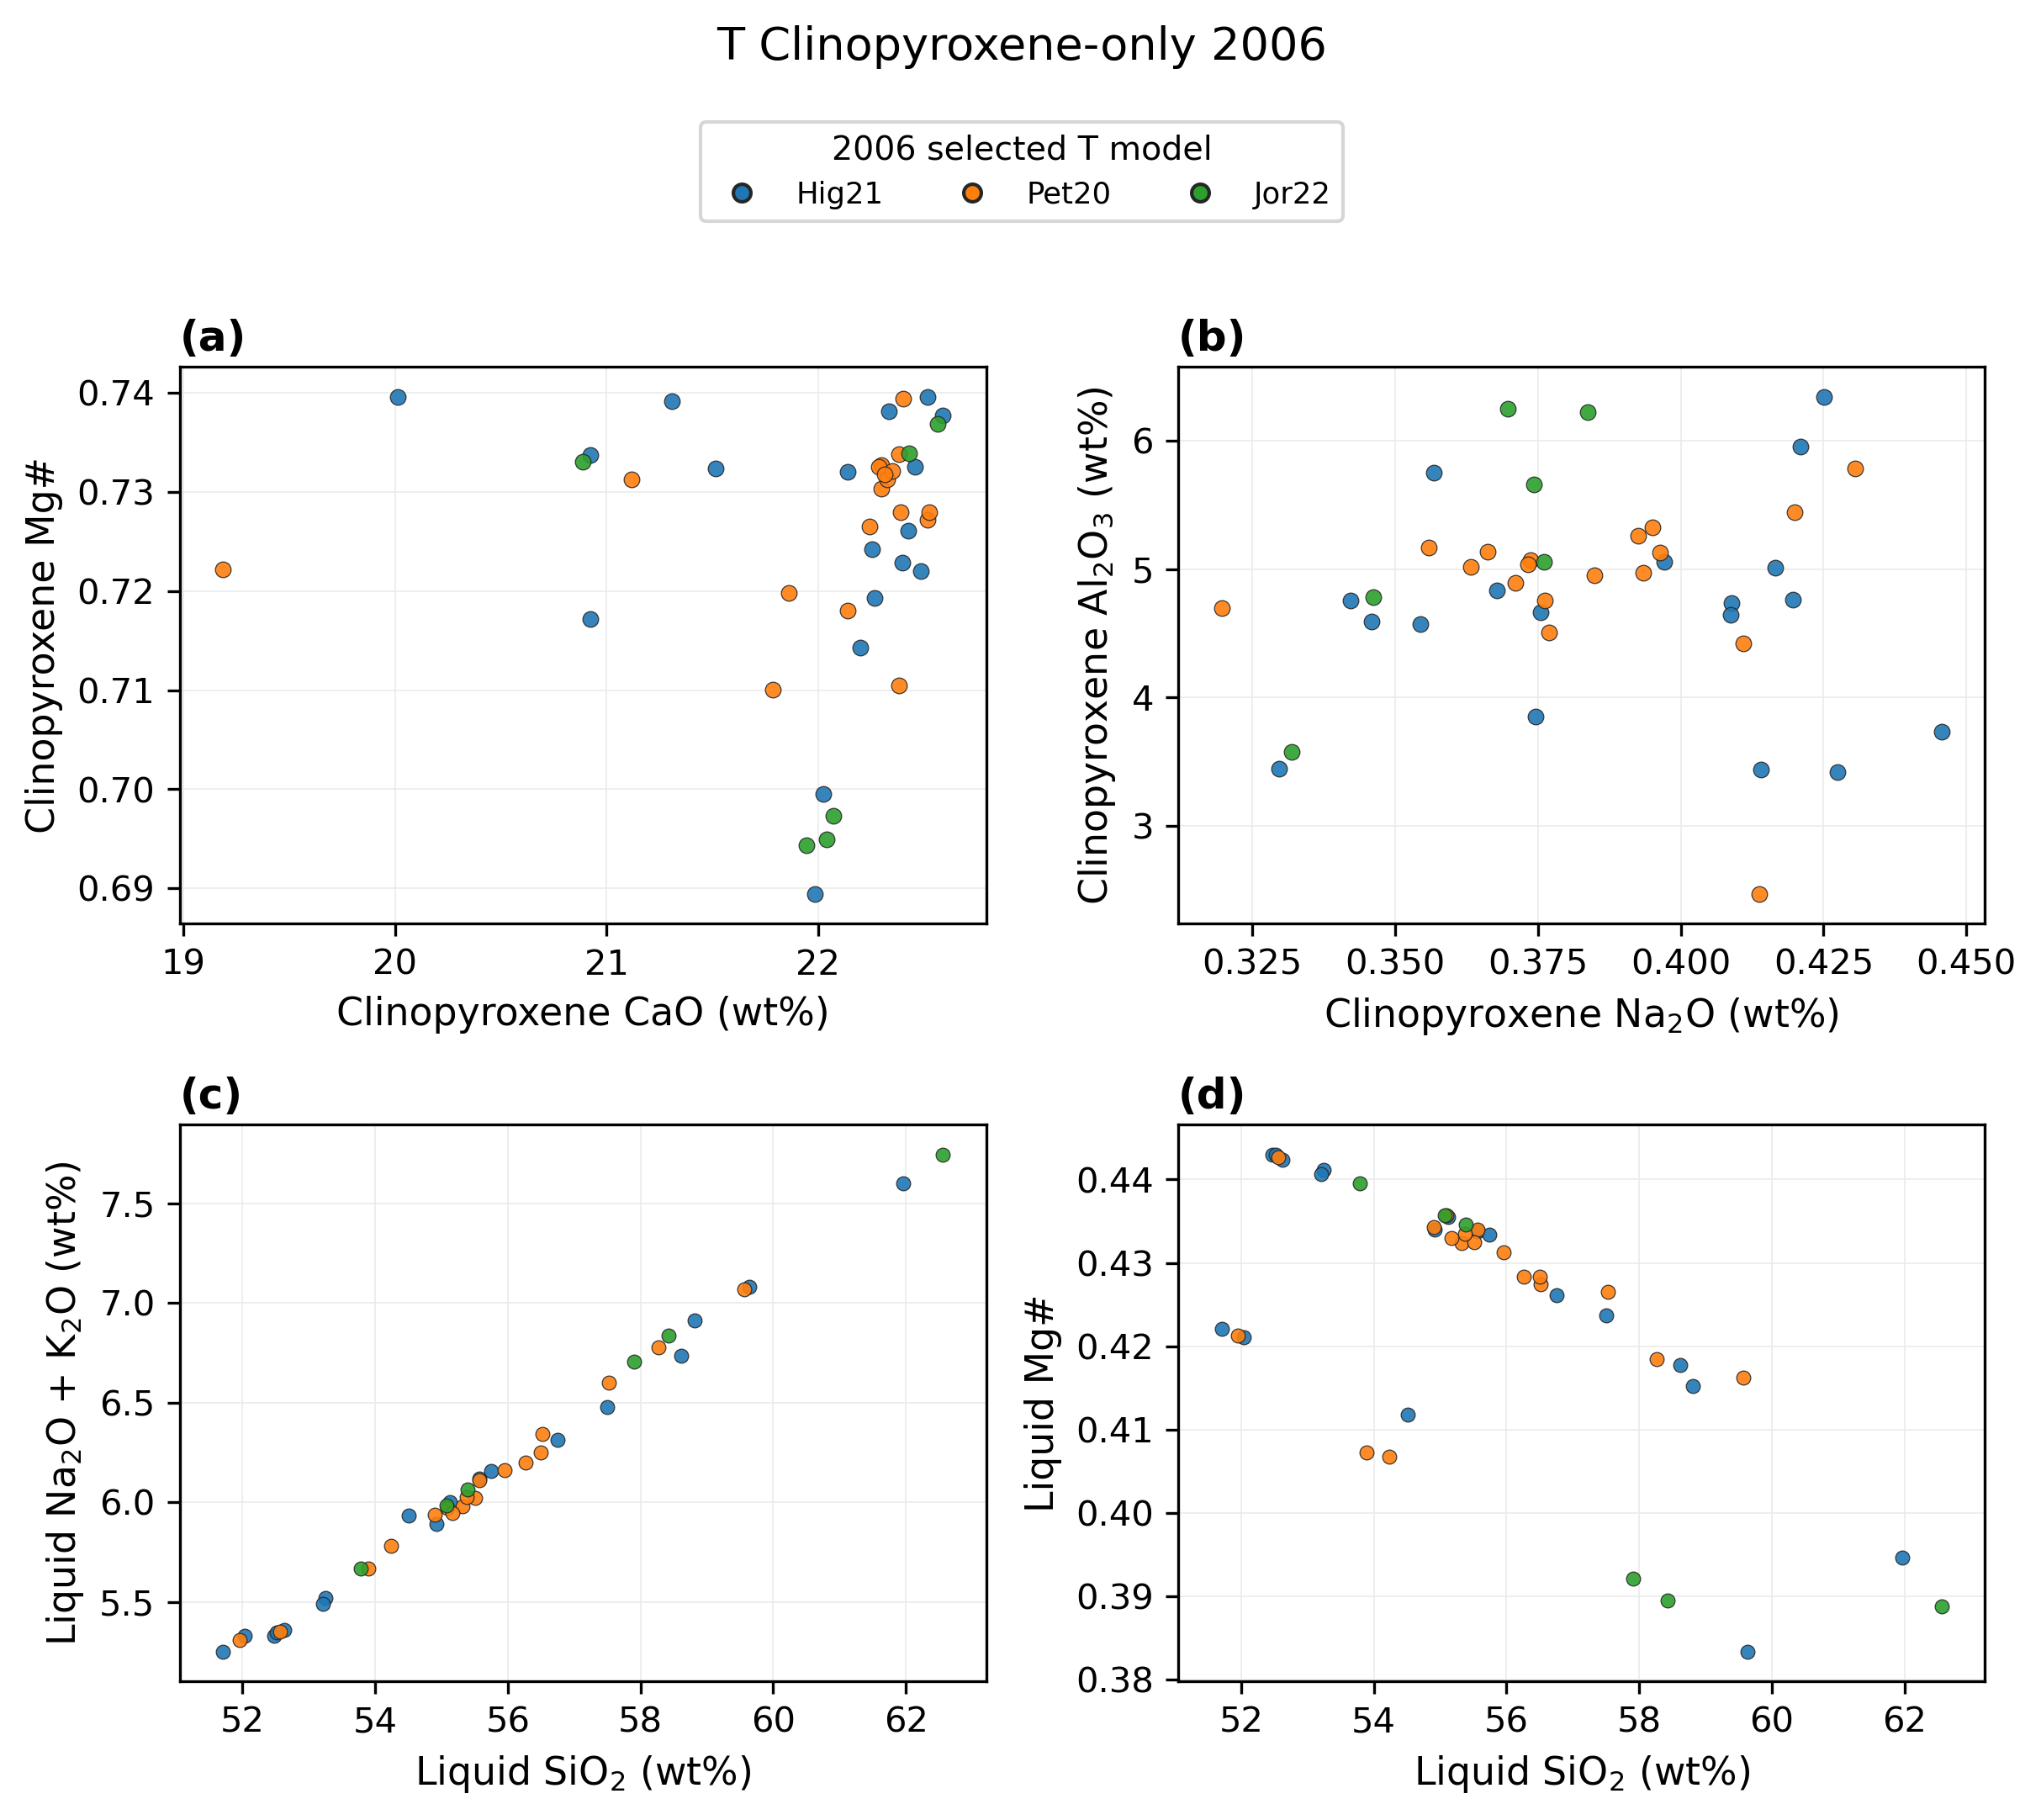

In [52]:
fig_t_cpx_only_2006, axes_t_cpx_only_2006, data_t_cpx_only_2006, models_t_cpx_only_2006 = plot_merapi_compositions_by_selected_model(
    year="2006",
    phase_label="Clinopyroxene-only",
    model_kind="T",
    workflow=workflow_cpx_only_T_06,
    figure_name="fig_7_Merapi_2006_compositions_by_selected_T_cpx_only_model",
)
plt.show()

#### T Clinopyroxene-only 2010

fig_7_Merapi_2010_compositions_by_selected_T_cpx_only_model


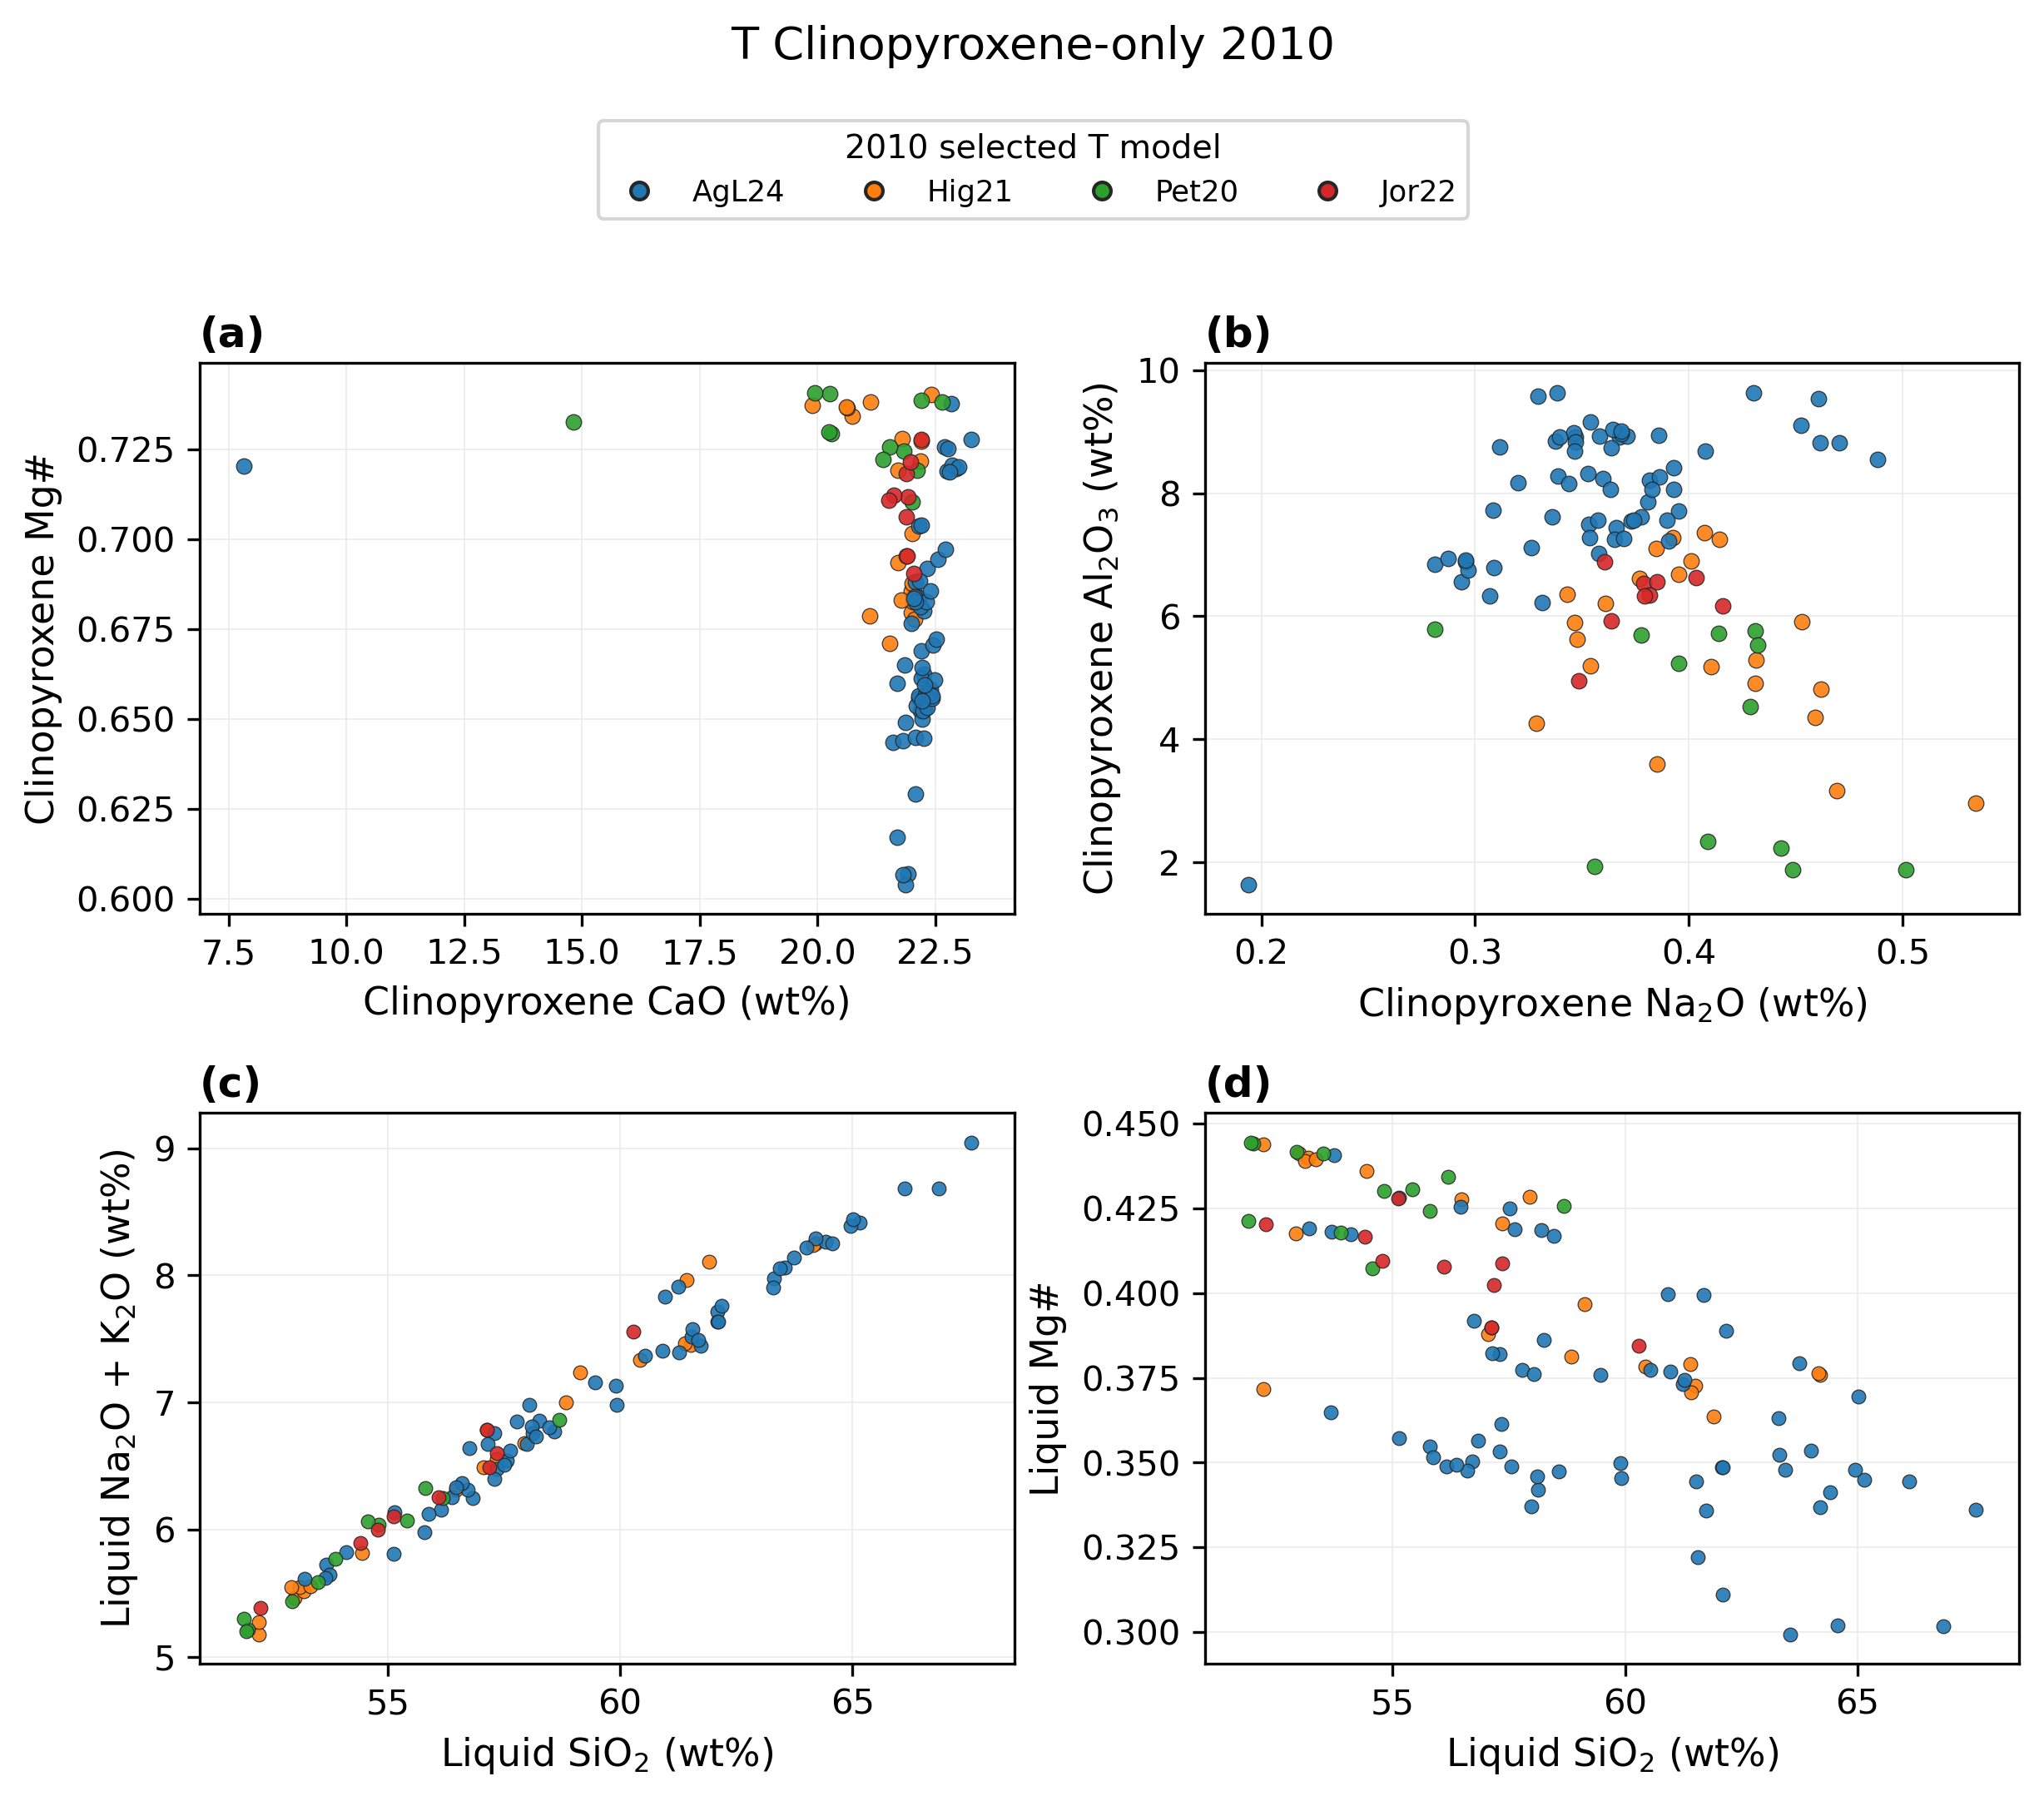

In [53]:
fig_t_cpx_only_2010, axes_t_cpx_only_2010, data_t_cpx_only_2010, models_t_cpx_only_2010 = plot_merapi_compositions_by_selected_model(
    year="2010",
    phase_label="Clinopyroxene-only",
    model_kind="T",
    workflow=workflow_cpx_only_T_10,
    figure_name="fig_7_Merapi_2010_compositions_by_selected_T_cpx_only_model",
)
plt.show()

#### T Clinopyroxene-liquid 2006

fig_7_Merapi_2006_compositions_by_selected_T_cpx_liq_model


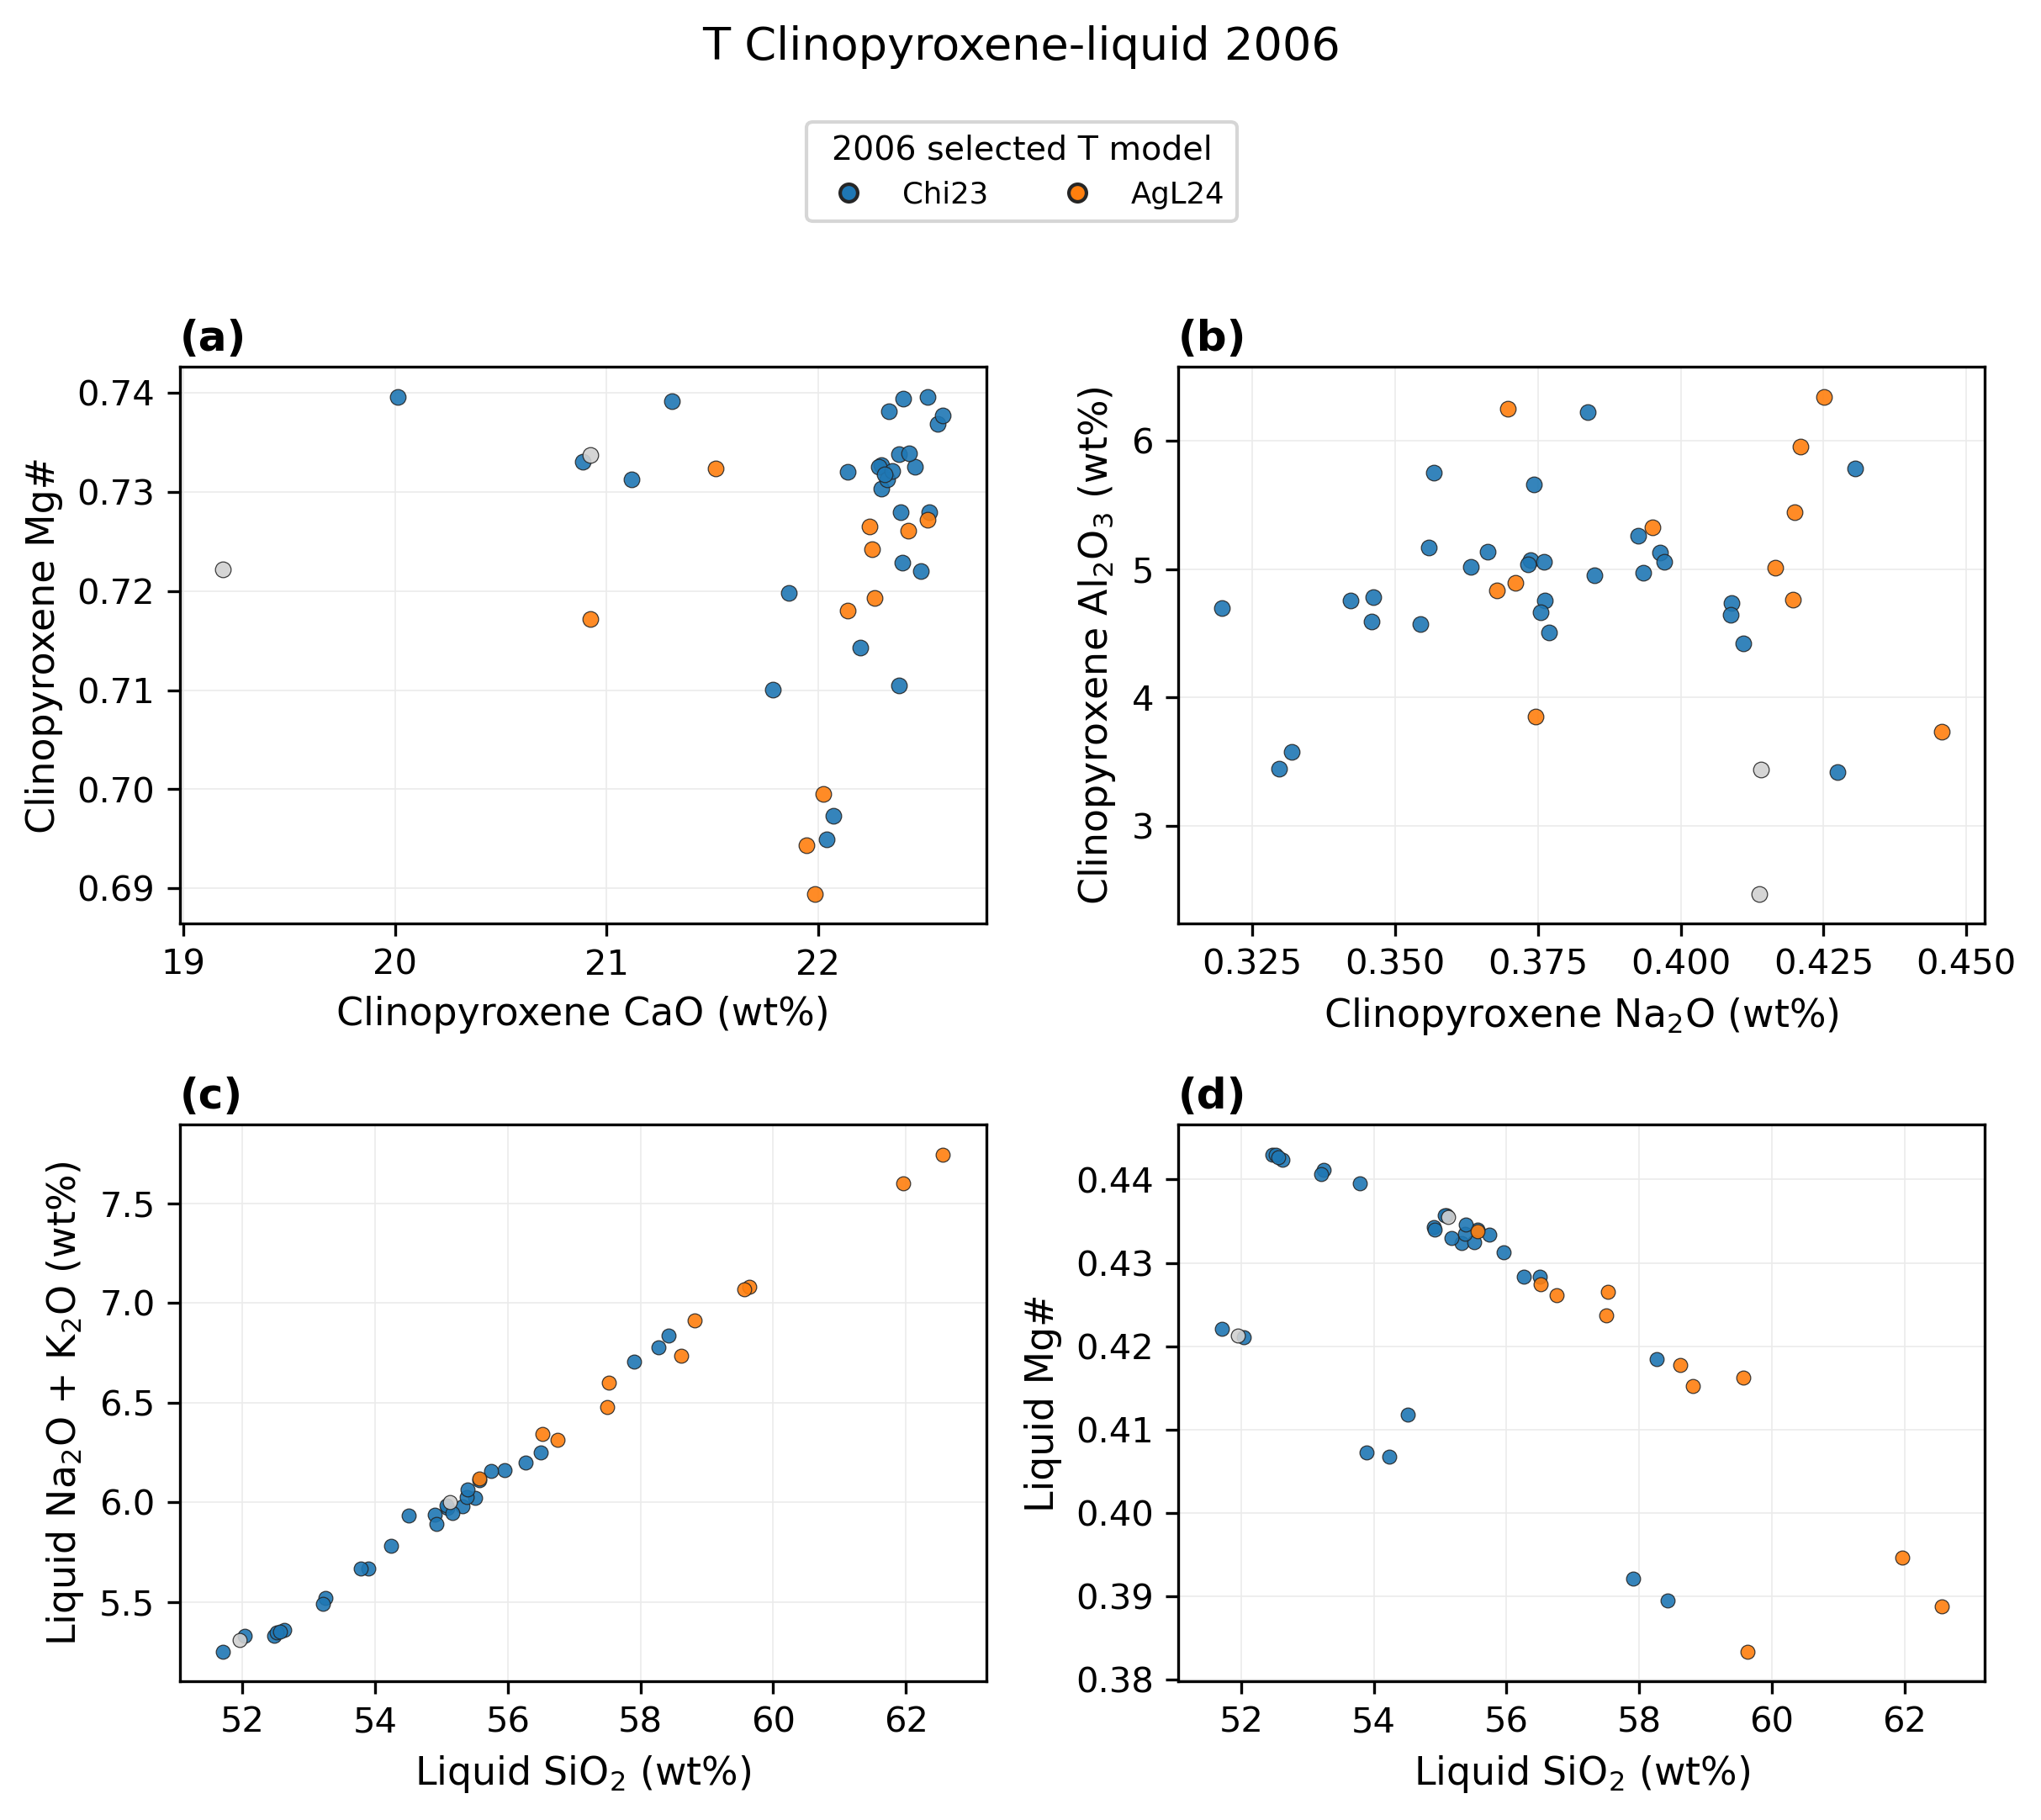

In [54]:
fig_t_cpx_liq_2006, axes_t_cpx_liq_2006, data_t_cpx_liq_2006, models_t_cpx_liq_2006 = plot_merapi_compositions_by_selected_model(
    year="2006",
    phase_label="Clinopyroxene-liquid",
    model_kind="T",
    workflow=workflow_cpx_liq_T_06,
    figure_name="fig_7_Merapi_2006_compositions_by_selected_T_cpx_liq_model",
)
plt.show()

#### T Clinopyroxene-liquid 2010

fig_7_Merapi_2010_compositions_by_selected_T_cpx_liq_model


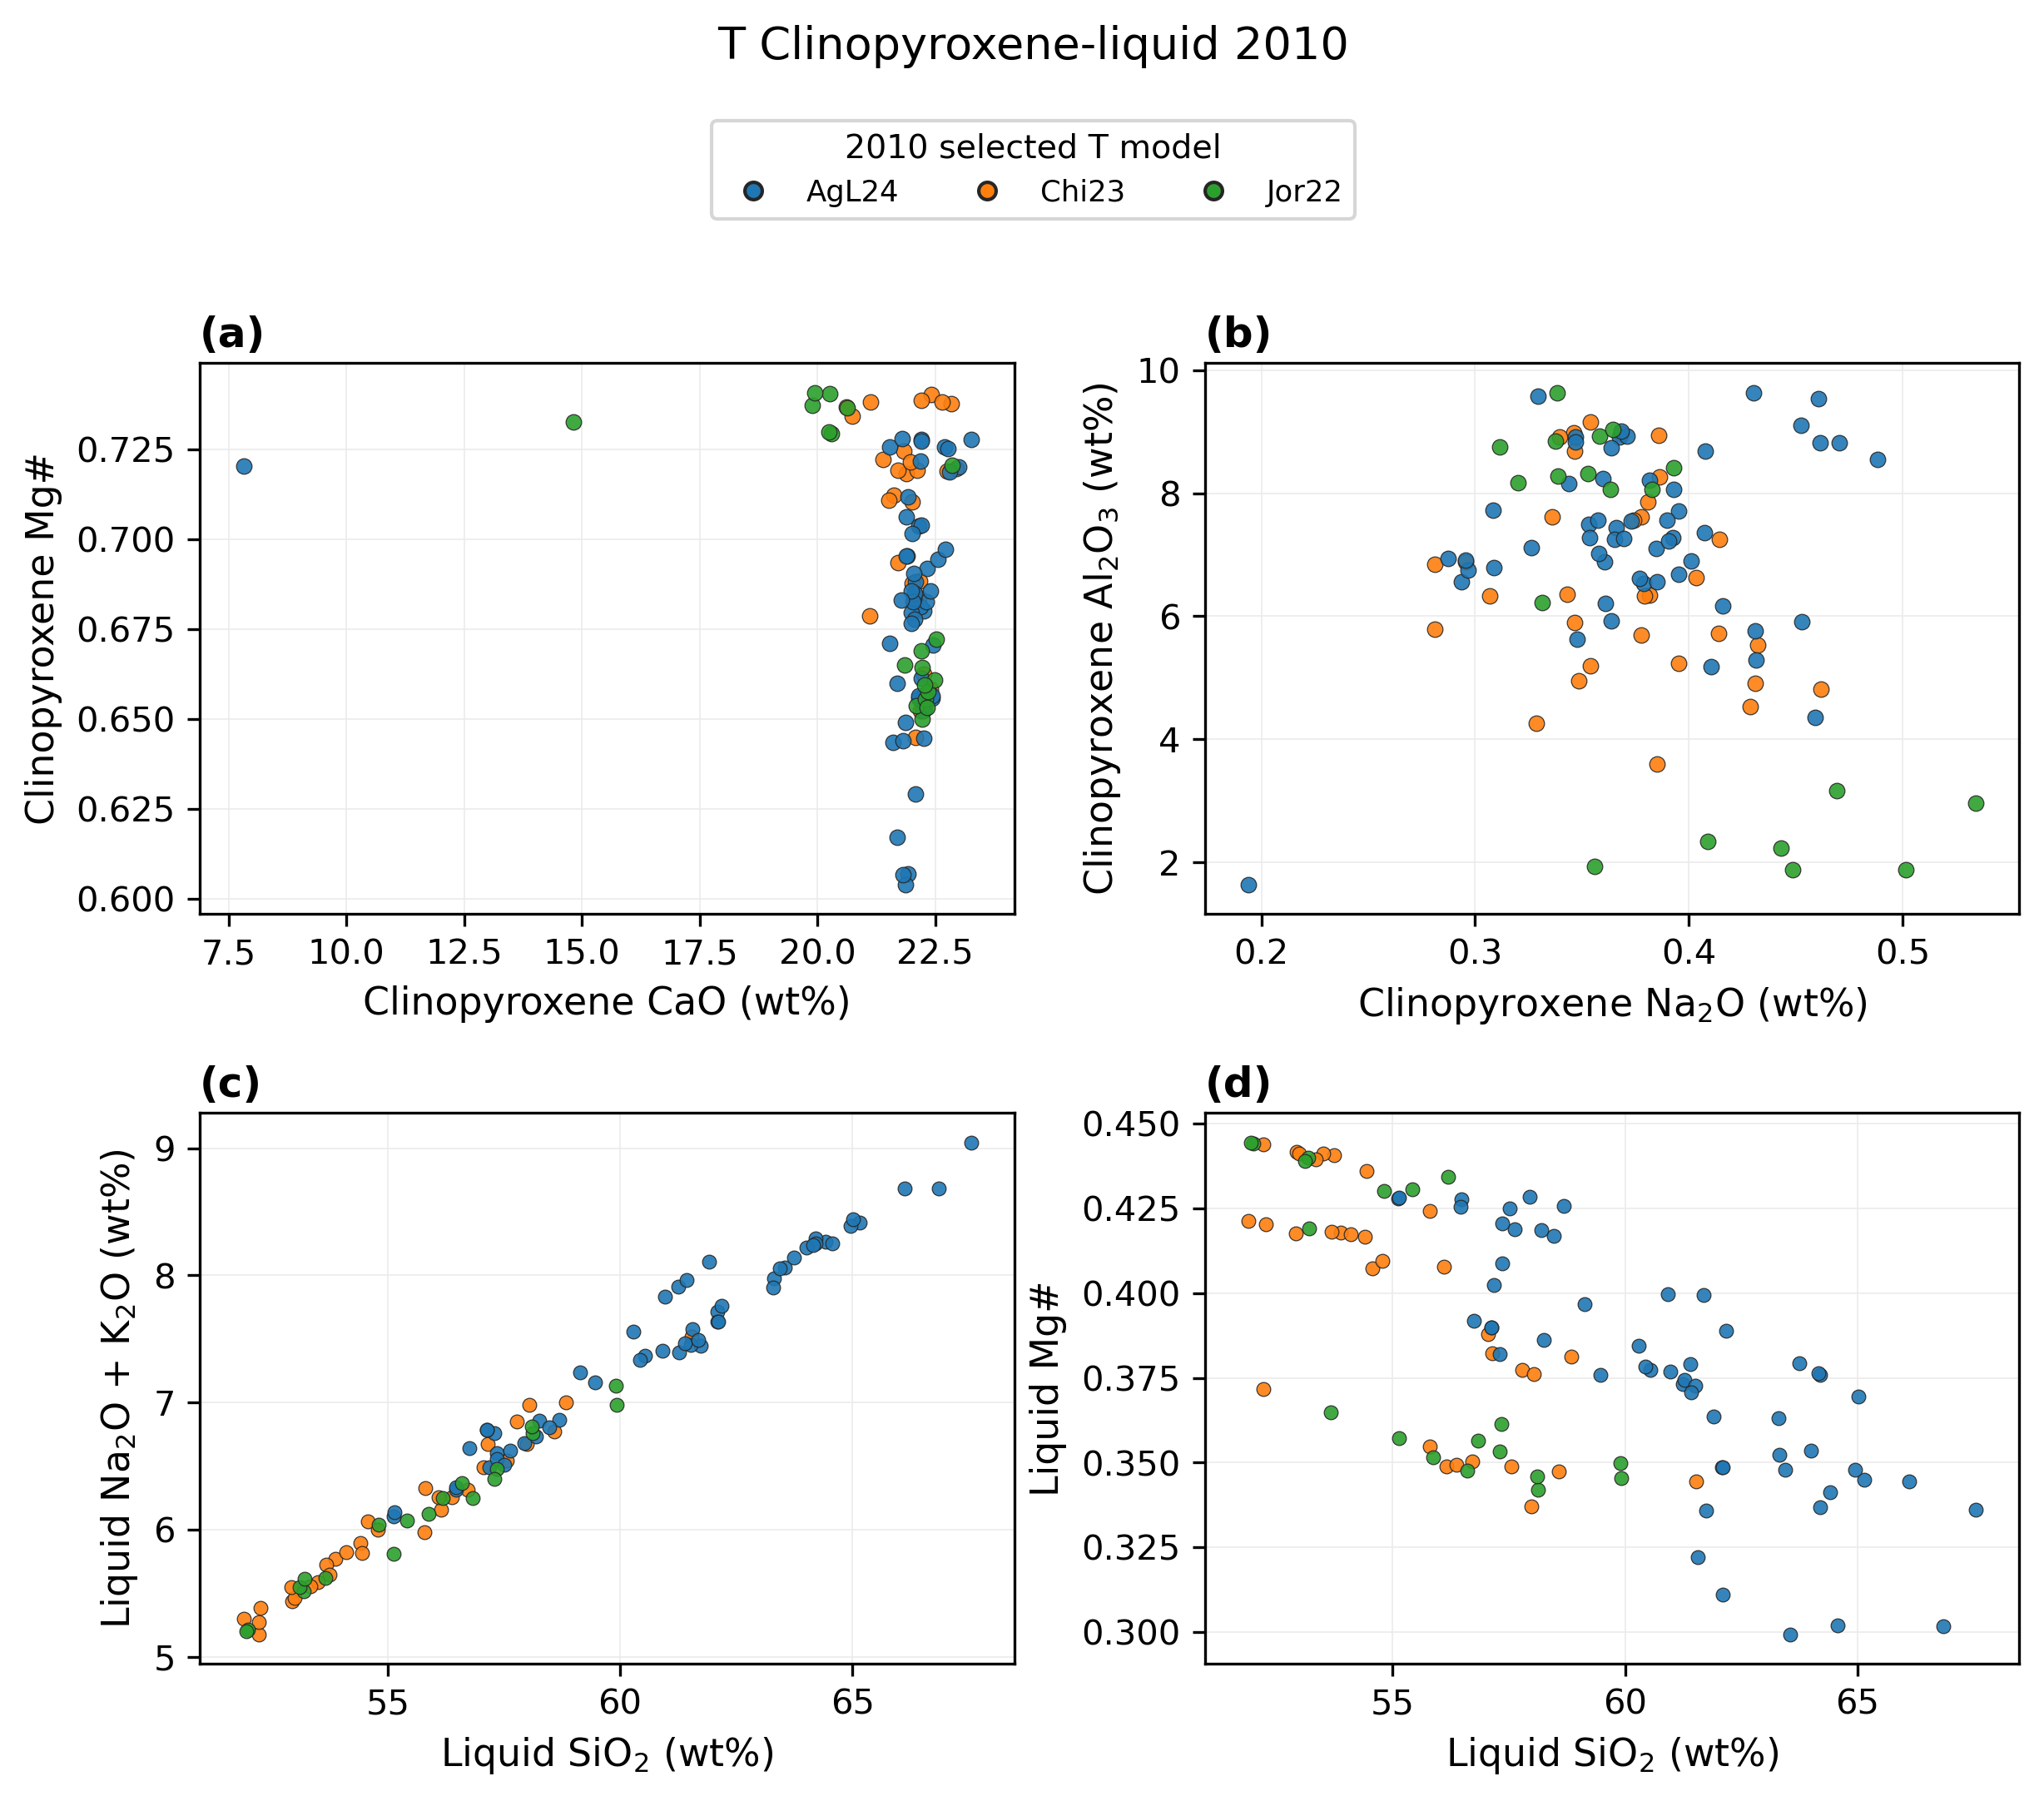

In [55]:
fig_t_cpx_liq_2010, axes_t_cpx_liq_2010, data_t_cpx_liq_2010, models_t_cpx_liq_2010 = plot_merapi_compositions_by_selected_model(
    year="2010",
    phase_label="Clinopyroxene-liquid",
    model_kind="T",
    workflow=workflow_cpx_liq_T_10,
    figure_name="fig_7_Merapi_2010_compositions_by_selected_T_cpx_liq_model",
)
plt.show()

低硅高镁多选 Petrelli 但是给的 P 反而低。为啥

如果jor 是对的，
但是Pe 看上去会高估 evolved 
看上去 petrelli 和 jor的结果比较一致的

## Cluster the 2006 and 2010 Compositions

Clustered pairs: 2006=42/42, 2010=106/106
Selected elbow k: 2006=3, 2010=3


,eruption_year,cluster,n_pairs,liq_SiO2_mean,liq_H2O_mean,dominant_model,dominant_model_frac
0,2006,1,7,54.066363,4.164942,"Jorgenson et al., 2022 (cpx_liq)",0.857143
1,2006,2,9,59.528749,4.547036,"Petrelli et al., 2020 (cpx_liq)",0.444444
2,2006,3,26,54.849171,4.219699,"Petrelli et al., 2020 (cpx_liq)",0.769231
3,2010,1,13,53.783484,4.145155,"Petrelli et al., 2020 (cpx_liq)",0.538462
4,2010,2,40,62.585157,4.760832,"Chicchi et al., 2023 (cpx_liq)",0.550000
5,2010,3,53,56.191914,4.313624,"Petrelli et al., 2020 (cpx_liq)",0.528302


selected_model         Chicchi et al., 2023 (cpx_liq)  \
eruption_year cluster                                   
2006          1                                  0.00   
              2                                  0.33   
              3                                  0.00   
2010          1                                  0.00   
              2                                  0.55   
              3                                  0.02   

selected_model         Jorgenson et al., 2022 (cpx_liq)  \
eruption_year cluster                                     
2006          1                                    0.86   
              2                                    0.22   
              3                                    0.12   
2010          1                                    0.38   
              2                                    0.42   
              3                                    0.19   

selected_model         Neave & Putirka, 2017 Pu08_eq33_T; eq1_P (cpx_liq) (cpx_liq)  \
eruption_year cluster                                                                 
2006          1                                                     0.00              
              2                                                     0.00              
              3                                                     0.04              
2010          1                                                     0.00              
              2                                                     0.00              
              3                                                     0.00              

selected_model         Petrelli et al., 2020 (cpx_liq)  \
eruption_year cluster                                    
2006          1                                   0.14   
              2                                   0.44   
              3                                   0.77   
2010          1                                   0.54   
              2                                   0.02   
              3                                   0.53   

selected_model         Ágreda-López et al., 2024 (cpx_liq)  
eruption_year cluster                                       
2006          1                                       0.00  
              2                                       0.00  
              3                                       0.08  
2010          1                                       0.08  
              2                                       0.00  
              3                                       0.26

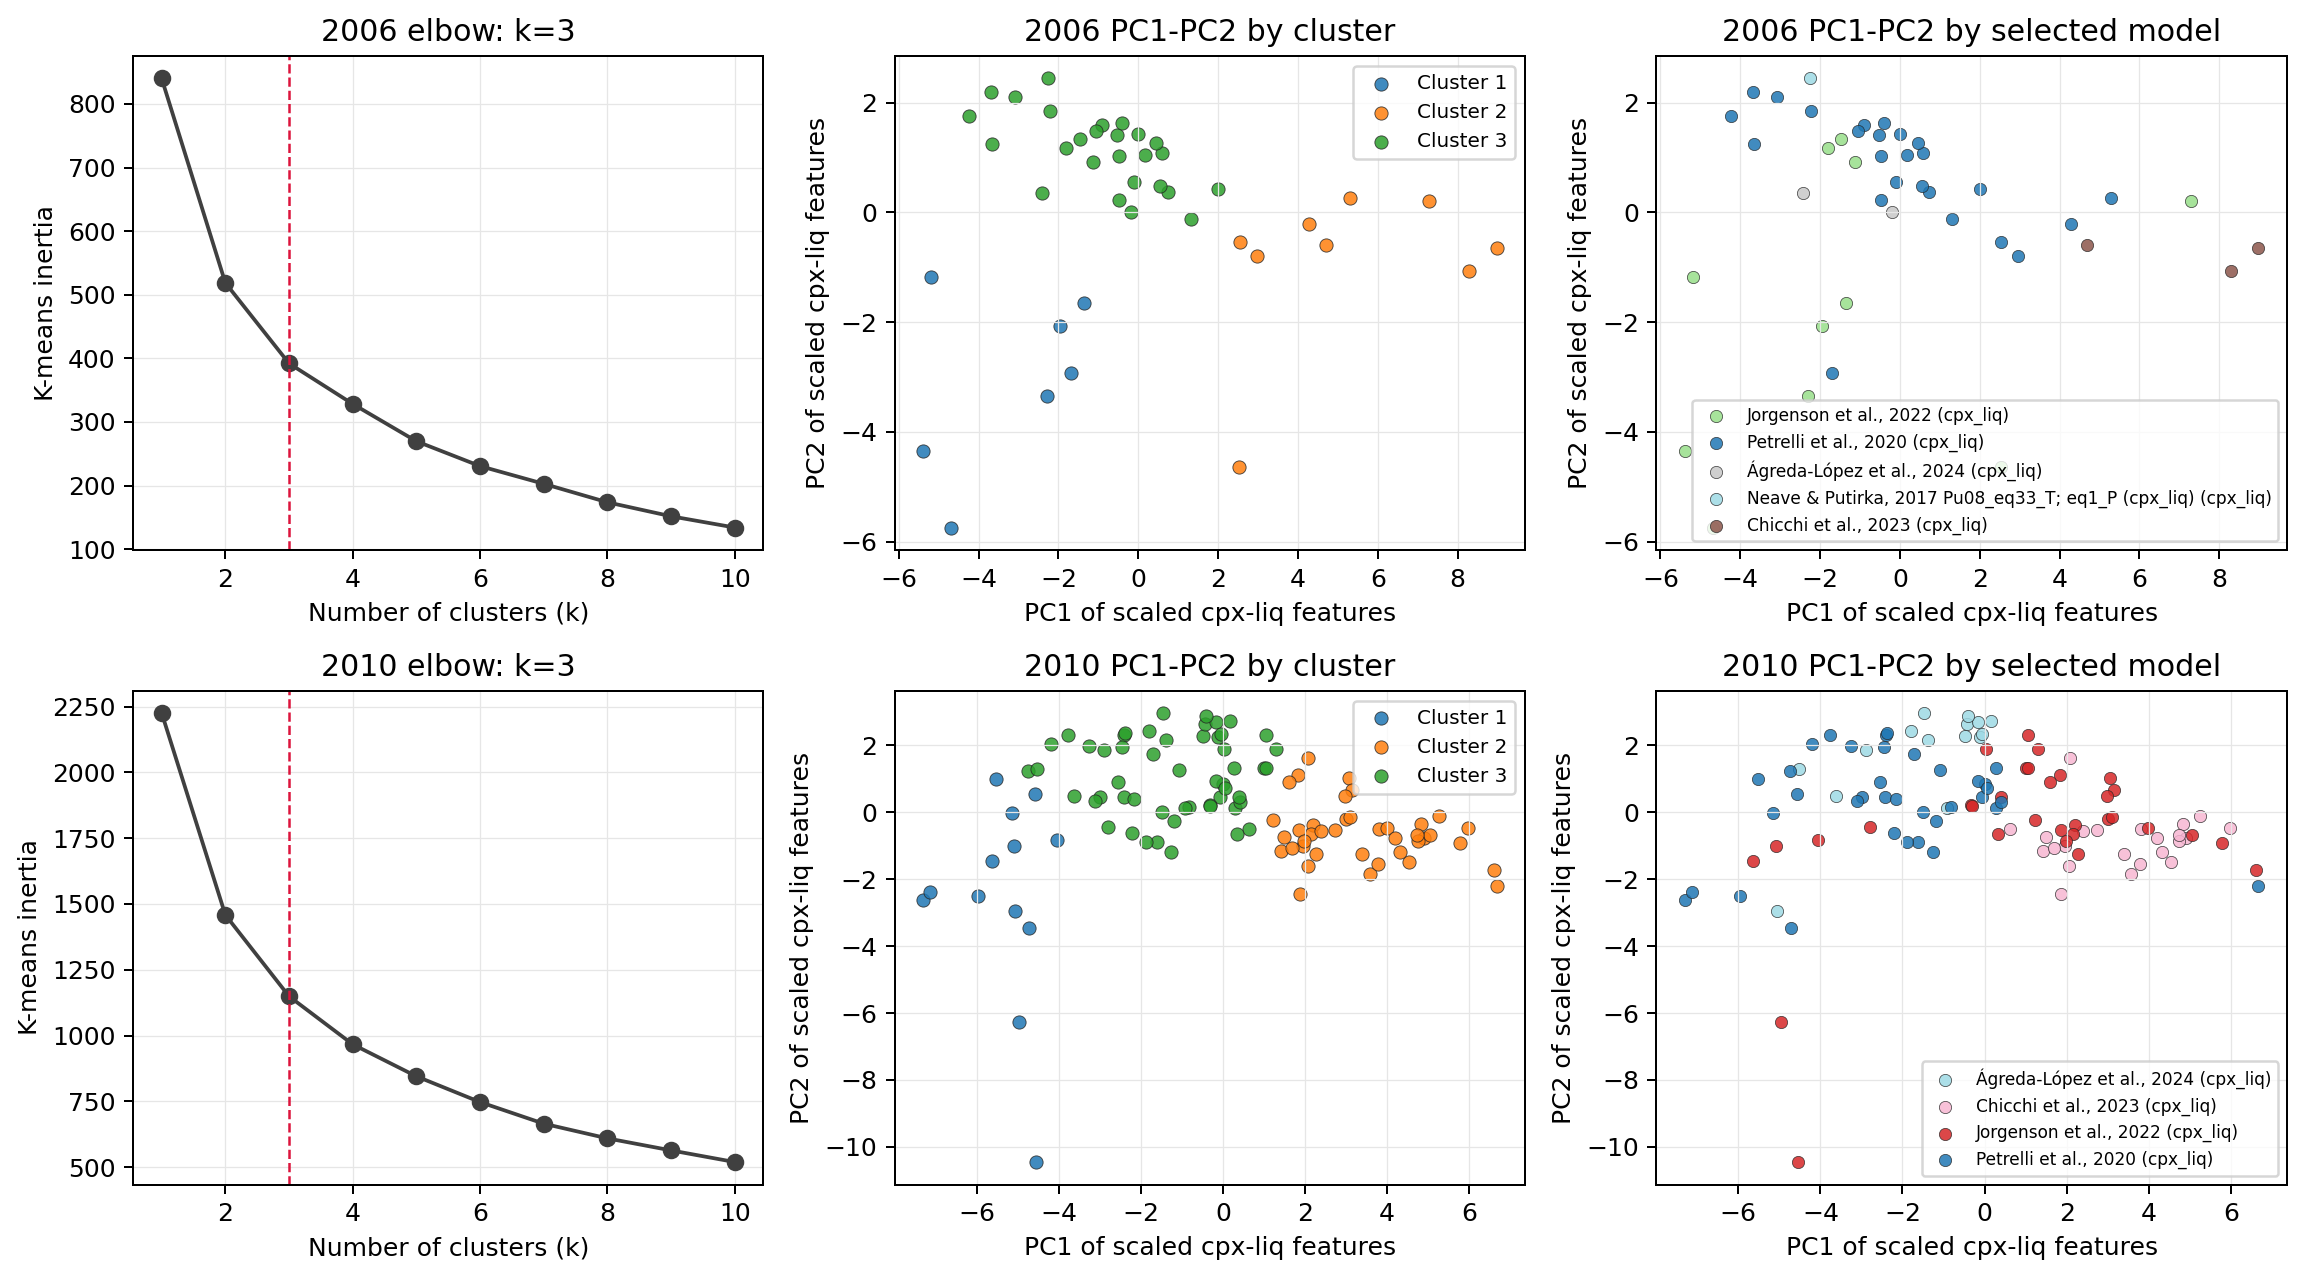

C:\Users\13493\AppData\Local\Temp\ipykernel_62932\545333677.py:275: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_model_overlap.tight_layout()


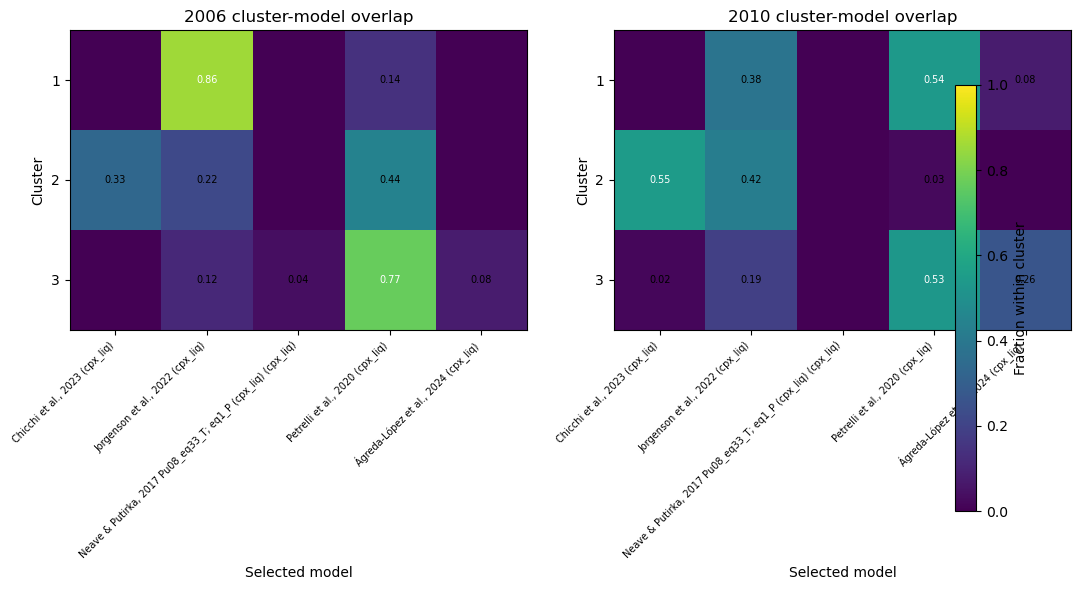

,eruption_year,pair_row,cluster,PC1,PC2,cpx__SiO2,cpx__TiO2,cpx__Al2O3,cpx__FeO,cpx__MnO,...,liq__TiO2,liq__Al2O3,liq__FeO,liq__MnO,liq__MgO,liq__CaO,liq__Na2O,liq__K2O,liq__H2O,selected_model
0,2006,0,1,-5.383516,-4.352284,50.742922,0.675655,3.419136,9.256879,0.628818,...,0.853159,18.396710,8.459665,0.205901,3.773473,9.289542,3.227157,2.102598,4.053654,"Jorgenson et al., 2022 (cpx_liq)"
1,2006,1,1,-1.357151,-1.649848,49.958897,0.932331,4.417043,8.972431,0.460150,...,0.800481,17.687145,7.617213,0.192576,3.255319,8.010625,3.305071,2.676073,4.252657,"Jorgenson et al., 2022 (cpx_liq)"
2,2006,2,2,2.964690,-0.798494,49.069929,1.013068,5.125703,9.046187,0.412471,...,0.701992,16.977296,6.541632,0.166291,2.640284,6.571571,3.381325,3.394064,4.458805,"Petrelli et al., 2020 (cpx_liq)"
3,2006,3,2,5.291774,0.262521,48.042978,1.000727,6.222483,9.638688,0.330210,...,0.678871,17.771161,5.575885,0.159267,1.995189,6.360020,3.662433,3.175361,4.470121,"Petrelli et al., 2020 (cpx_liq)"
4,2006,4,3,-0.189997,0.005632,49.064653,0.825188,5.260575,9.389521,0.364525,...,0.781715,18.753360,6.887165,0.185266,2.649298,8.236530,3.469398,2.310271,4.176826,"Ágreda-López et al., 2024 (cpx_liq)"


In [56]:
from sklearn.cluster import KMeans
from aims4pt.statistic_tools.elbow_point import find_elbow_point

cpx_cols = [
    "SiO2", "TiO2", "Al2O3", "FeO", "MnO", "MgO",
    "CaO", "Na2O", "K2O", "Cr2O3", "NiO",
]
liq_cols = [
    "SiO2", "TiO2", "Al2O3", "FeO", "MnO", "MgO",
    "CaO", "Na2O", "K2O", "H2O",
]

pairing_cache_2006 = CACHE_DIR / "merapi_2006_pairing_kd028_err1e-4_n20000_endmembers.xlsx"
pairs_06, pairs_pass_mask_06, paired_cpx_06, paired_liq_06 = read_pairing_cache(pairing_cache_2006)
paired_cpx_06_pass = paired_cpx_06[pairs_pass_mask_06].reset_index(drop=True)
paired_liq_06_pass = paired_liq_06[pairs_pass_mask_06].reset_index(drop=True)

workflow_path_2006 = CACHE_DIR / f"marapi_2006_P_workflow_cpx_liq_P_{timestamp}.pkl"
if not workflow_path_2006.exists():
    raise FileNotFoundError(f"Missing cached workflow: {workflow_path_2006}")
with open(workflow_path_2006, "rb") as f:
    workflow_cpx_liq_P_06 = pkl.load(f)

for _liq in (paired_liq_06_pass, paired_liq_10_pass):
    _liq["H2O"] = pd.to_numeric(_liq["SiO2"], errors="coerce") * 0.06995 + 0.383


def _build_cpx_liq_feature_frame(cpx_df, liq_df):
    """Build an imputed cpx-liquid feature matrix with explicit feature prefixes."""
    missing_cpx = [col for col in cpx_cols if col not in cpx_df.columns]
    missing_liq = [col for col in liq_cols if col not in liq_df.columns]
    if missing_cpx or missing_liq:
        raise KeyError(f"Missing cpx columns {missing_cpx} or liquid columns {missing_liq}")

    cpx_features = cpx_df[cpx_cols].apply(pd.to_numeric, errors="coerce")
    liq_features = liq_df[liq_cols].apply(pd.to_numeric, errors="coerce")
    cpx_features.columns = [f"cpx__{col}" for col in cpx_features.columns]
    liq_features.columns = [f"liq__{col}" for col in liq_features.columns]
    features = pd.concat([cpx_features, liq_features], axis=1)
    features = features.replace([np.inf, -np.inf], np.nan)
    fill_values = features.median(axis=0, skipna=True).fillna(0.0)
    return features.fillna(fill_values)


def _standardize_features(features):
    """Standardize feature columns before clustering."""
    mean = features.mean(axis=0)
    std = features.std(axis=0, ddof=0).replace(0, 1.0)
    scaled = (features - mean) / std
    return scaled.to_numpy(dtype=float), mean, std


def _run_kmeans(scaled, k, random_state=42):
    """Run sklearn k-means and return one-based labels plus inertia."""
    model = KMeans(n_clusters=k, random_state=random_state, n_init=50)
    labels = model.fit_predict(scaled)
    return model.cluster_centers_, labels + 1, float(model.inertia_)


def _pca_scores_numpy(scaled, n_components=2, random_state=42, max_iter=500, tol=1e-9):
    """Return PCA-like scores using power iteration for plotting."""
    centered = scaled - scaled.mean(axis=0, keepdims=True)
    cov = centered.T @ centered / max(centered.shape[0] - 1, 1)
    rng = np.random.default_rng(random_state)
    components = []
    work_cov = cov.copy()
    for _ in range(n_components):
        vec = rng.normal(size=work_cov.shape[0])
        vec = vec / np.sqrt(np.sum(vec * vec))
        for _ in range(max_iter):
            next_vec = work_cov @ vec
            length = np.sqrt(np.sum(next_vec * next_vec))
            if length == 0:
                break
            next_vec = next_vec / length
            if np.sqrt(np.sum((next_vec - vec) ** 2)) < tol:
                vec = next_vec
                break
            vec = next_vec
        eigenvalue = float(vec @ work_cov @ vec)
        components.append(vec.copy())
        work_cov = work_cov - eigenvalue * np.outer(vec, vec)
    return centered @ np.vstack(components).T


def _align_selected_models_to_result(workflow, result):
    """Align workflow-selected model labels to clustered pair rows."""
    selected = workflow.get_best_model_series().astype("object")
    if len(selected) == len(result):
        values = selected.to_numpy()
    else:
        values = pd.Series(np.nan, index=result.index, dtype="object")
        common = result["pair_row"].astype(int).to_numpy()
        valid = common < len(selected)
        values.loc[result.index[valid]] = selected.iloc[common[valid]].to_numpy()
        values = values.to_numpy()
    out = result.copy()
    out["selected_model"] = pd.Series(values, index=out.index).where(lambda s: s.notna(), "No selected model")
    return out


def _cluster_one_year(cpx_df, liq_df, workflow, year, max_k=10, random_state=42):
    """Scale features, select k by elbow_point.py, and run k-means for one eruption year."""
    features = _build_cpx_liq_feature_frame(cpx_df, liq_df)
    if features.empty:
        raise ValueError(f"No cpx-liquid feature rows available for {year}.")

    scaled, mean, std = _standardize_features(features)
    max_k = min(max_k, len(features))
    ks = list(range(1, max_k + 1))
    inertias = []
    for k in ks:
        _, _, inertia = _run_kmeans(scaled, k, random_state=random_state)
        inertias.append(inertia)

    elbow_curve = pd.DataFrame(
        {
            "eruption_year": str(year),
            "k": ks,
            "inertia": inertias,
        }
    )
    elbow_k = find_elbow_point(
        elbow_curve,
        x_col="k",
        y_col="inertia",
        curve="convex",
        direction="decreasing",
        plot=False,
    )
    if elbow_k is None:
        raise ValueError(f"No elbow point detected for {year}.")
    elbow_k = int(elbow_k)
    elbow_curve["selected_k"] = elbow_k

    centroids, cluster, final_inertia = _run_kmeans(scaled, elbow_k, random_state=random_state)
    scores = _pca_scores_numpy(scaled, n_components=2)
    result = pd.DataFrame(
        {
            "eruption_year": str(year),
            "pair_row": features.index,
            "cluster": cluster,
            "PC1": scores[:, 0],
            "PC2": scores[:, 1],
        },
        index=features.index,
    )
    result = pd.concat([result, features], axis=1)
    result = _align_selected_models_to_result(workflow, result)

    summary = (
        result.groupby("cluster")
        .agg(
            n_pairs=("pair_row", "size"),
            liq_SiO2_mean=("liq__SiO2", "mean"),
            liq_H2O_mean=("liq__H2O", "mean"),
            dominant_model=("selected_model", lambda s: s.value_counts().idxmax()),
            dominant_model_frac=("selected_model", lambda s: s.value_counts(normalize=True).max()),
        )
        .reset_index()
    )
    summary.insert(0, "eruption_year", str(year))
    return {
        "year": str(year),
        "features": features,
        "scaled": scaled,
        "feature_mean": mean,
        "feature_std": std,
        "centroids": centroids,
        "final_inertia": final_inertia,
        "elbow_k": elbow_k,
        "elbow_curve": elbow_curve,
        "result": result,
        "summary": summary,
    }


merapi_cluster_results = {
    "2006": _cluster_one_year(paired_cpx_06_pass, paired_liq_06_pass, workflow_cpx_liq_P_06, "2006"),
    "2010": _cluster_one_year(paired_cpx_10_pass, paired_liq_10_pass, workflow_cpx_liq_P_10, "2010"),
}
merapi_pair_clusters = pd.concat([item["result"] for item in merapi_cluster_results.values()], ignore_index=True)
merapi_cluster_summaries = pd.concat([item["summary"] for item in merapi_cluster_results.values()], ignore_index=True)
merapi_elbow_curves = pd.concat([item["elbow_curve"] for item in merapi_cluster_results.values()], ignore_index=True)
merapi_cluster_model_counts = pd.crosstab(
    [merapi_pair_clusters["eruption_year"], merapi_pair_clusters["cluster"]],
    merapi_pair_clusters["selected_model"],
)
merapi_cluster_model_fracs = merapi_cluster_model_counts.div(merapi_cluster_model_counts.sum(axis=1), axis=0)

print(
    "Clustered pairs: "
    f"2006={len(merapi_cluster_results['2006']['result'])}/{len(paired_cpx_06_pass)}, "
    f"2010={len(merapi_cluster_results['2010']['result'])}/{len(paired_cpx_10_pass)}"
)
print(
    "Selected elbow k: "
    f"2006={merapi_cluster_results['2006']['elbow_k']}, "
    f"2010={merapi_cluster_results['2010']['elbow_k']}"
)
display(merapi_cluster_summaries)
display(merapi_cluster_model_fracs.round(2))

fig_cluster, axes_cluster = plt.subplots(2, 3, figsize=(13.2, 7.2), dpi=180)
for row, (year, cluster_state) in enumerate(merapi_cluster_results.items()):
    elbow = cluster_state["elbow_curve"]
    selected_k = cluster_state["elbow_k"]
    result = cluster_state["result"]

    ax_elbow = axes_cluster[row, 0]
    ax_elbow.plot(elbow["k"], elbow["inertia"], marker="o", color="0.25", linewidth=1.5)
    ax_elbow.axvline(selected_k, color="crimson", linestyle="--", linewidth=1.0)
    ax_elbow.set_title(f"{year} elbow: k={selected_k}")
    ax_elbow.set_xlabel("Number of clusters (k)")
    ax_elbow.set_ylabel("K-means inertia")
    ax_elbow.grid(True, color="0.9", linewidth=0.5)

    ax_cluster = axes_cluster[row, 1]
    for cluster_id, group in result.groupby("cluster", sort=True):
        ax_cluster.scatter(
            group["PC1"],
            group["PC2"],
            s=28,
            edgecolors="0.15",
            linewidths=0.35,
            alpha=0.85,
            label=f"Cluster {cluster_id}",
        )
    ax_cluster.set_title(f"{year} PC1-PC2 by cluster")
    ax_cluster.set_xlabel("PC1 of scaled cpx-liq features")
    ax_cluster.set_ylabel("PC2 of scaled cpx-liq features")
    ax_cluster.grid(True, color="0.9", linewidth=0.5)
    ax_cluster.legend(frameon=True, fontsize=8)

    ax_model = axes_cluster[row, 2]
    model_order = result["selected_model"].value_counts().index.tolist()
    model_colors = {model: plt.get_cmap("tab20", max(len(model_order), 1))(i) for i, model in enumerate(model_order)}
    for model_name, group in result.groupby("selected_model", sort=False):
        ax_model.scatter(
            group["PC1"],
            group["PC2"],
            s=24,
            edgecolors="0.15",
            linewidths=0.3,
            alpha=0.85,
            color=model_colors.get(model_name, "0.7"),
            label=str(model_name),
        )
    ax_model.set_title(f"{year} PC1-PC2 by selected model")
    ax_model.set_xlabel("PC1 of scaled cpx-liq features")
    ax_model.set_ylabel("PC2 of scaled cpx-liq features")
    ax_model.grid(True, color="0.9", linewidth=0.5)
    ax_model.legend(frameon=True, fontsize=6.8, loc="best")

fig_cluster.tight_layout()
plt.show()

fig_model_overlap, axes_model_overlap = plt.subplots(1, 2, figsize=(11.0, 6), dpi=100)
for ax, year in zip(axes_model_overlap, ["2006", "2010"]):
    year_frac = merapi_cluster_model_fracs.loc[year]
    im = ax.imshow(year_frac.to_numpy(), aspect="auto", cmap="viridis", vmin=0, vmax=1)
    ax.set_title(f"{year} cluster-model overlap")
    ax.set_xlabel("Selected model")
    ax.set_ylabel("Cluster")
    ax.set_xticks(np.arange(year_frac.shape[1]))
    ax.set_xticklabels(year_frac.columns.astype(str), rotation=45, ha="right", fontsize=7)
    ax.set_yticks(np.arange(year_frac.shape[0]))
    ax.set_yticklabels(year_frac.index.astype(str))
    for i in range(year_frac.shape[0]):
        for j in range(year_frac.shape[1]):
            value = year_frac.iat[i, j]
            if value > 0:
                ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7, color="white" if value > 0.5 else "black")
fig_model_overlap.colorbar(im, ax=axes_model_overlap, fraction=0.025, pad=0.02, label="Fraction within cluster")
fig_model_overlap.tight_layout()
plt.show()

merapi_pair_clusters.head()